In [1]:
# import json

# def process_backprop_time(filename, output_filename):
#     # 加载原始数据
#     with open(filename) as f:
#         data = json.load(f)
    
#     # 修改所有Back_propagation time数据
#     for iteration in data['iterations']:
#         if 'Back_propagation time' in iteration['timing']:
#             iteration['timing']['Back_propagation time'] *= 60
    
#     # 保存修改后的数据
#     with open(output_filename, 'w') as f:
#         json.dump(data, f, indent=2)
    
#     print(f"已处理并保存: {output_filename}")

# # 处理两个文件
# process_backprop_time('FEMoo_time.json', 'FEMoo_time.json')

In [1]:
import json
import matplotlib.pyplot as plt
import numpy as np

# 加载JSON数据
with open('FEg_time.json') as f:
    data = json.load(f)

# 提取所有timing数据
timings = []
for iteration in data['iterations']:
    timings.append(iteration['timing'])

# 准备绘图数据
components = list(timings[0].keys())
iterations = range(501)
component_data = {comp: [t[comp] for t in timings] for comp in components}


# 修改图例名称的映射
legend_names = {
    'Geometry_ini': 'Geometry_initialization',
    'FDM_time': 'FDM_time',
    'FE_time': 'FE_time',
    'Loss calculation': 'Loss cal_time',
    'Back_propagation time': 'Backpropagation_time',
    'ParametersUpgrade': 'Parametric Update'
}

plt.figure(figsize=(12, 8))
for comp in components:
    # 使用映射后的图例名称
    plt.plot(iterations, component_data[comp], label=legend_names[comp])
plt.xlabel('Iteration')
plt.ylabel('Time (seconds)')
plt.title('Timing Components Over 501 Iterations')
plt.legend()
plt.grid(True)
plt.show()

KeyError: 'timing'

In [ ]:
# 计算平均值
averages = {comp: np.mean(component_data[comp]) for comp in components}

# 绘制平均时间柱状图
plt.figure(figsize=(10, 6))
plt.bar(components, averages.values())
plt.xlabel('Component')
plt.ylabel('Average Time (seconds)')
plt.title('Average Timing Across 501 Iterations')
plt.xticks(rotation=45)
plt.grid(True, axis='y')
plt.show()

In [ ]:
# 找出最大值及对应迭代
max_values = {}
max_iterations = {}
for comp in components:
    max_val = max(component_data[comp])
    max_iter = component_data[comp].index(max_val)
    max_values[comp] = max_val
    max_iterations[comp] = max_iter

# 绘制最大时间柱状图
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(components, max_values.values())
ax.set_xlabel('Component')
ax.set_ylabel('Maximum Time (seconds)')
ax.set_title('Maximum Timing Across 501 Iterations (with Iteration Number)')
ax.grid(True, axis='y')

# 在柱子上方添加迭代次数标签
for bar, comp in zip(bars, components):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'Iter {max_iterations[comp]}',
            ha='center', va='bottom')

plt.xticks(rotation=45)
plt.show()

共同比较的组件: {'FE_time_g', 'Geometry_ini', 'ParametersUpgrade', 'Back_propagation time', 'Earlystopping', 'FE_time_x', 'FE_time_y'}


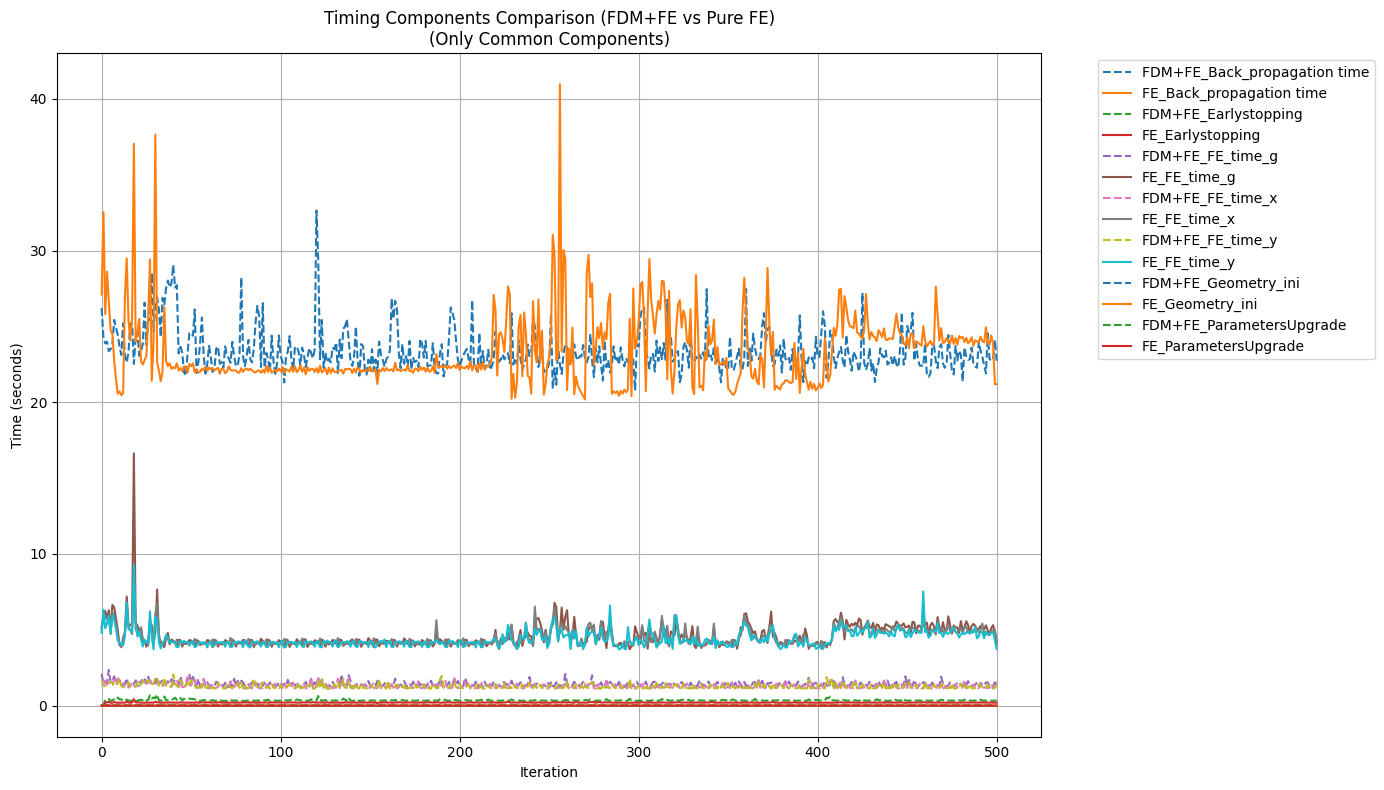

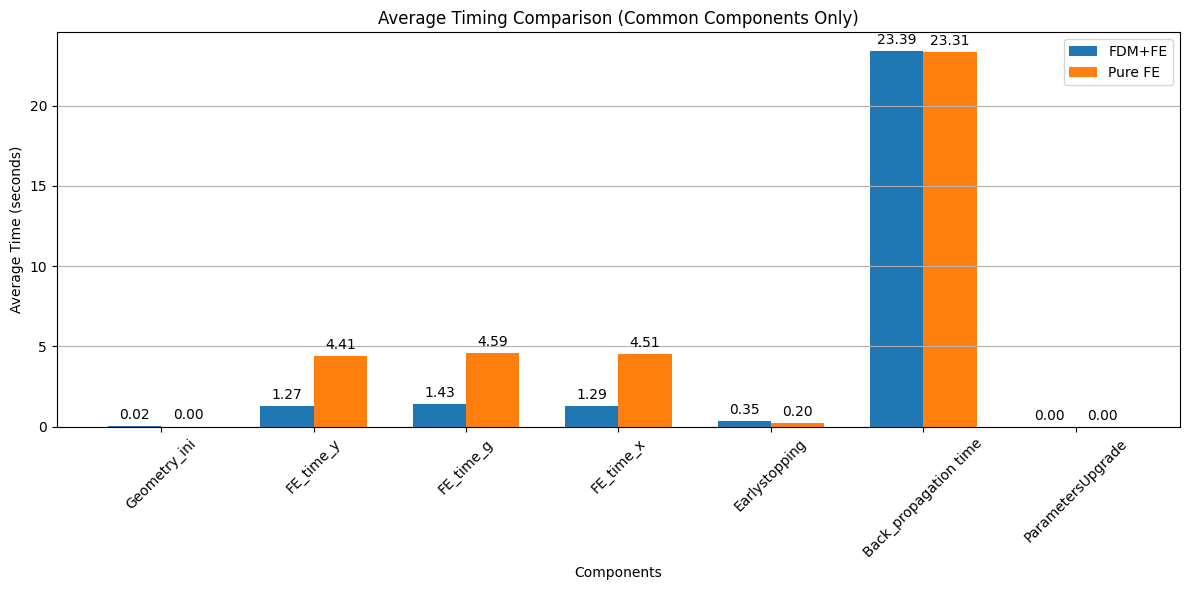

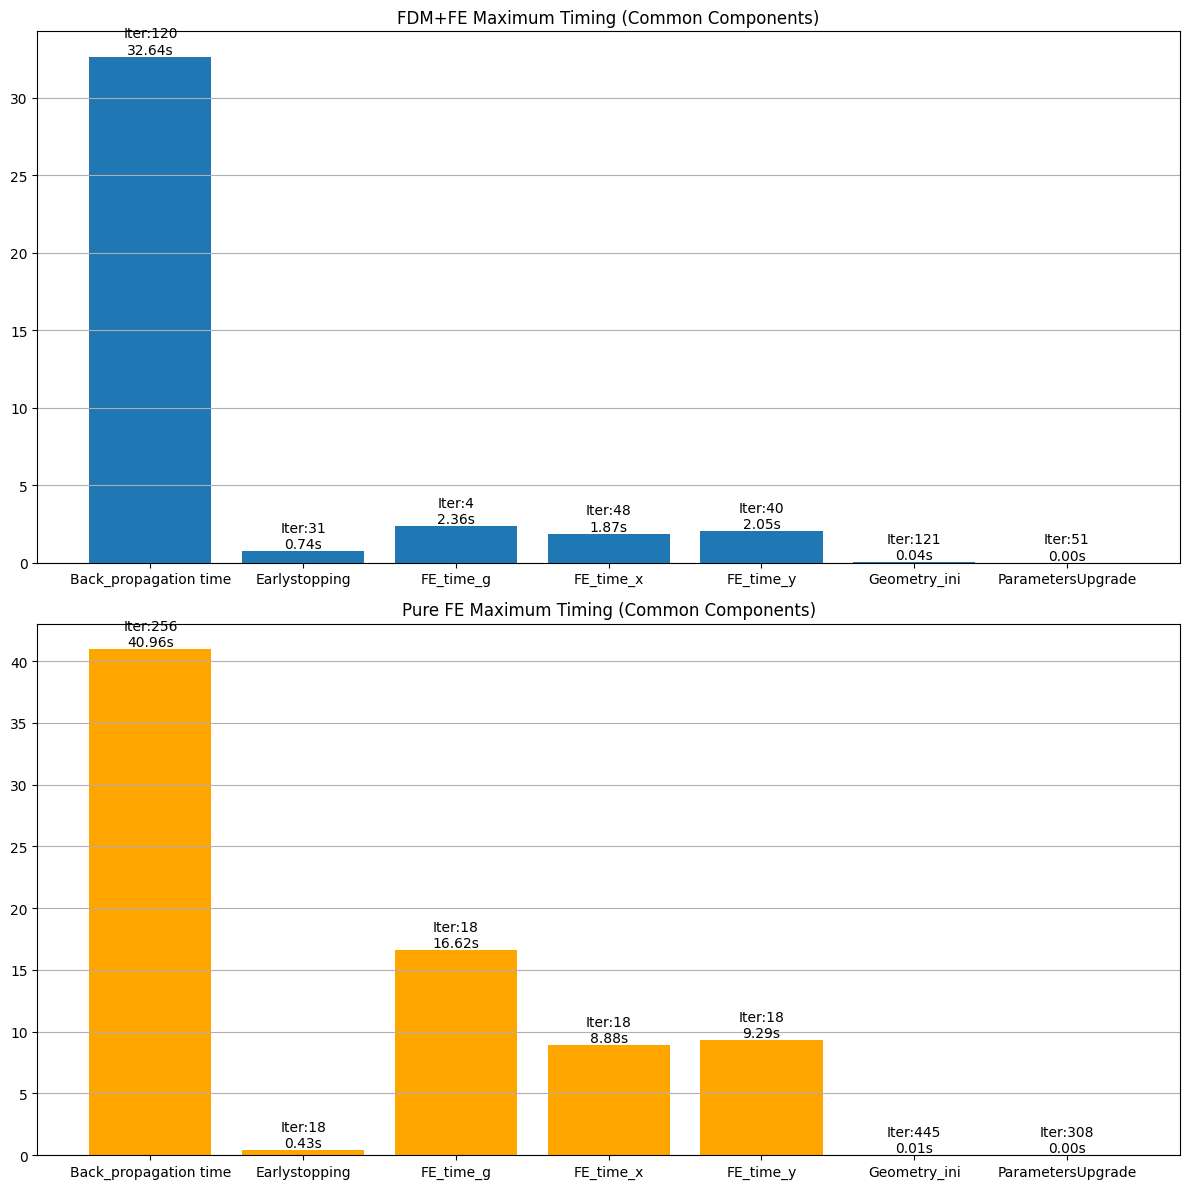

In [2]:
import json
import matplotlib.pyplot as plt
import numpy as np

# 加载两个JSON文件
with open('Moo_time.json') as f1, open('FEMoo_time.json') as f2:
    data_fdm = json.load(f1)  # 原始FDM+FE数据
    data_fem = json.load(f2)  # 新FE数据

# 提取timing数据函数
def extract_timing_data(data):
    return [iteration['timing'] for iteration in data['iterations']]

timings_fdm = extract_timing_data(data_fdm)
timings_fem = extract_timing_data(data_fem)

# 找出两个文件共有的timing组件
common_components = set(timings_fdm[0].keys()) & set(timings_fem[0].keys())
print("共同比较的组件:", common_components)
plt.figure(figsize=(14, 8))
for comp in sorted(common_components):  # 按字母排序保证顺序一致
    # FDM+FE数据
    plt.plot(range(501), [t[comp] for t in timings_fdm], 
             linestyle='--', label=f'FDM+FE_{comp}')
    # 纯FE数据
    plt.plot(range(501), [t[comp] for t in timings_fem],
             label=f'FE_{comp}')

plt.xlabel('Iteration')
plt.ylabel('Time (seconds)')
plt.title('Timing Components Comparison (FDM+FE vs Pure FE)\n(Only Common Components)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

# 计算平均值
# 定义正确的组件顺序
correct_order = [
    'Geometry_ini',
    'FE_time_y', 
    'FE_time_g',
    'FE_time_x',
    'Earlystopping',
    'Back_propagation time',
    'ParametersUpgrade'
]

# 筛选出两个文件共有的组件，并按照指定顺序排列
common_components = [comp for comp in correct_order if comp in timings_fdm[0] and comp in timings_fem[0]]

# 计算平均值
avg_fdm = {comp: np.mean([t[comp] for t in timings_fdm]) for comp in common_components}
avg_fem = {comp: np.mean([t[comp] for t in timings_fem]) for comp in common_components}

# 绘制对比柱状图
x = np.arange(len(common_components))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, [avg_fdm[comp] for comp in common_components], 
               width, label='FDM+FE')
bars2 = ax.bar(x + width/2, [avg_fem[comp] for comp in common_components], 
               width, label='Pure FE')

# 设置图表属性
ax.set_xlabel('Components')
ax.set_ylabel('Average Time (seconds)')
ax.set_title('Average Timing Comparison (Common Components Only)')
ax.set_xticks(x)
ax.set_xticklabels(common_components, rotation=45)  # 使用已排序的标签
ax.legend()
ax.grid(True, axis='y')

# 添加数值标签
for bars in (bars1, bars2):
    for bar, comp in zip(bars, common_components):
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                   xy=(bar.get_x() + bar.get_width() / 2, height),
                   xytext=(0, 3),
                   textcoords="offset points",
                   ha='center', va='bottom')

plt.tight_layout()
plt.show()

# 找出最大值及迭代位置
def find_max(timings, components):
    max_vals = {}
    max_iters = {}
    for comp in components:
        values = [t[comp] for t in timings]
        max_val = max(values)
        max_iter = values.index(max_val)
        max_vals[comp] = max_val
        max_iters[comp] = max_iter
    return max_vals, max_iters

max_fdm, iter_fdm = find_max(timings_fdm, common_components)
max_fem, iter_fem = find_max(timings_fem, common_components)

# 绘制对比图
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))

# FDM+FE最大时间
bars1 = ax1.bar(sorted(common_components), [max_fdm[comp] for comp in sorted(common_components)])
ax1.set_title('FDM+FE Maximum Timing (Common Components)')
ax1.grid(True, axis='y')
for bar, comp in zip(bars1, sorted(common_components)):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height,
            f'Iter:{iter_fdm[comp]}\n{height:.2f}s',
            ha='center', va='bottom')

# Pure FE最大时间
bars2 = ax2.bar(sorted(common_components), [max_fem[comp] for comp in sorted(common_components)], 
                color='orange')
ax2.set_title('Pure FE Maximum Timing (Common Components)')
ax2.grid(True, axis='y')
for bar, comp in zip(bars2, sorted(common_components)):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, height,
            f'Iter:{iter_fem[comp]}\n{height:.2f}s',
            ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [3]:
# 计算标准差
std_fdm = {comp: np.std([t[comp] for t in timings_fdm]) for comp in common_components}
std_fem = {comp: np.std([t[comp] for t in timings_fem]) for comp in common_components}

# 打印标准差结果
print("FDM+FE方法各组件标准差:")
for comp, val in std_fdm.items():
    print(f"{comp}: {val:.4f}秒")

print("\n纯FE方法各组件标准差:")
for comp, val in std_fem.items():
    print(f"{comp}: {val:.4f}秒")

FDM+FE方法各组件标准差:
Geometry_ini: 0.0026秒
FE_time_y: 0.1672秒
FE_time_g: 0.1692秒
FE_time_x: 0.1657秒
Earlystopping: 0.0533秒
Back_propagation time: 1.4065秒
ParametersUpgrade: 0.0001秒

纯FE方法各组件标准差:
Geometry_ini: 0.0006秒
FE_time_y: 0.5535秒
FE_time_g: 0.8329秒
FE_time_x: 0.5643秒
Earlystopping: 0.0200秒
Back_propagation time: 2.3297秒
ParametersUpgrade: 0.0000秒


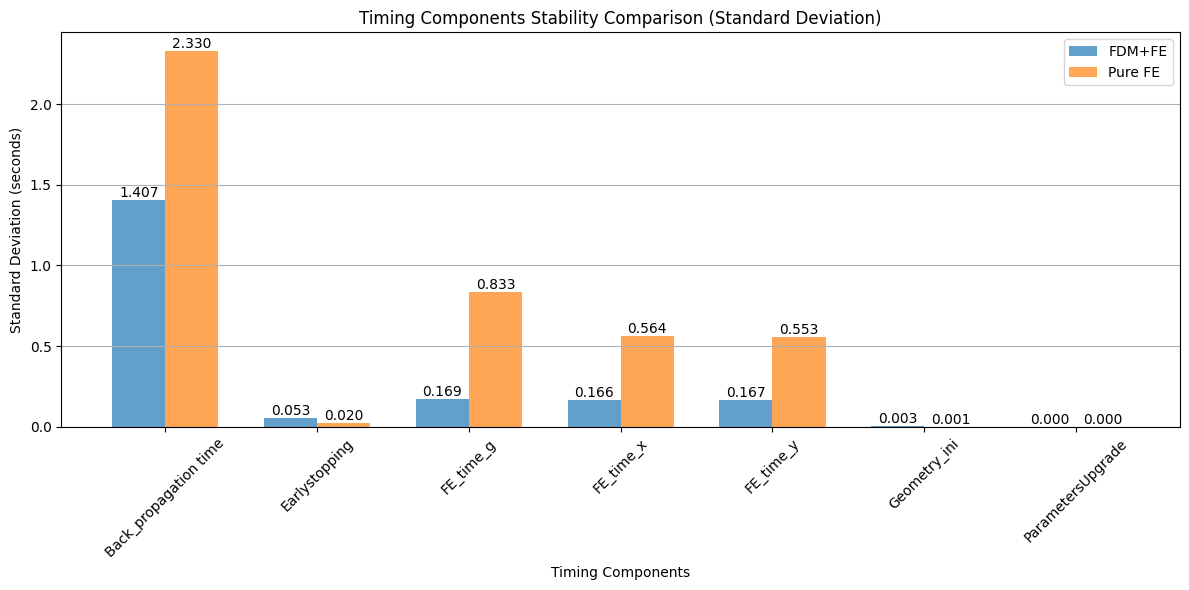


综合统计对比表:


,Component,FDM+FE_Avg,FDM+FE_Std,FE_Avg,FE_Std,Avg_Diff%,Std_Diff%
0,Back_propagation time,23.394,1.407,23.312,2.330,-0.3%,65.6%
1,Earlystopping,0.351,0.053,0.203,0.020,-42.0%,-62.5%
2,FE_time_g,1.432,0.169,4.590,0.833,220.5%,392.1%
3,FE_time_x,1.287,0.166,4.514,0.564,250.8%,240.5%
4,FE_time_y,1.272,0.167,4.414,0.553,246.9%,231.0%
5,Geometry_ini,0.018,0.003,0.003,0.001,-81.7%,-76.9%
6,ParametersUpgrade,0.001,0.000,0.000,0.000,-72.5%,-63.8%


In [4]:
# 准备数据
components_sorted = sorted(common_components)
x = np.arange(len(components_sorted))
width = 0.35

# 创建图表
plt.figure(figsize=(12, 6))

# 绘制柱状图
bars1 = plt.bar(x - width/2, [std_fdm[comp] for comp in components_sorted], 
                width, label='FDM+FE', alpha=0.7)
bars2 = plt.bar(x + width/2, [std_fem[comp] for comp in components_sorted], 
                width, label='Pure FE', alpha=0.7)

# 添加标注
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom')

add_labels(bars1)
add_labels(bars2)

# 图表装饰
plt.xlabel('Timing Components')
plt.ylabel('Standard Deviation (seconds)')
plt.title('Timing Components Stability Comparison (Standard Deviation)')
plt.xticks(x, components_sorted, rotation=45)
plt.legend()
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

import pandas as pd

# 创建统计对比表格
stats_comparison = pd.DataFrame({
    'Component': components_sorted,
    'FDM+FE_Avg': [avg_fdm[comp] for comp in components_sorted],
    'FDM+FE_Std': [std_fdm[comp] for comp in components_sorted],
    'FE_Avg': [avg_fem[comp] for comp in components_sorted],
    'FE_Std': [std_fem[comp] for comp in components_sorted],
    'Avg_Diff%': [(avg_fem[comp]-avg_fdm[comp])/avg_fdm[comp]*100 
                 for comp in components_sorted],
    'Std_Diff%': [(std_fem[comp]-std_fdm[comp])/std_fdm[comp]*100 
                 for comp in components_sorted]
})

# 显示表格
print("\n综合统计对比表:")
display(stats_comparison.style.format({
    'FDM+FE_Avg': '{:.3f}',
    'FDM+FE_Std': '{:.3f}',
    'FE_Avg': '{:.3f}',
    'FE_Std': '{:.3f}',
    'Avg_Diff%': '{:.1f}%',
    'Std_Diff%': '{:.1f}%'
}).bar(color=['#d65f5f', '#5fba7d'], align='zero'))

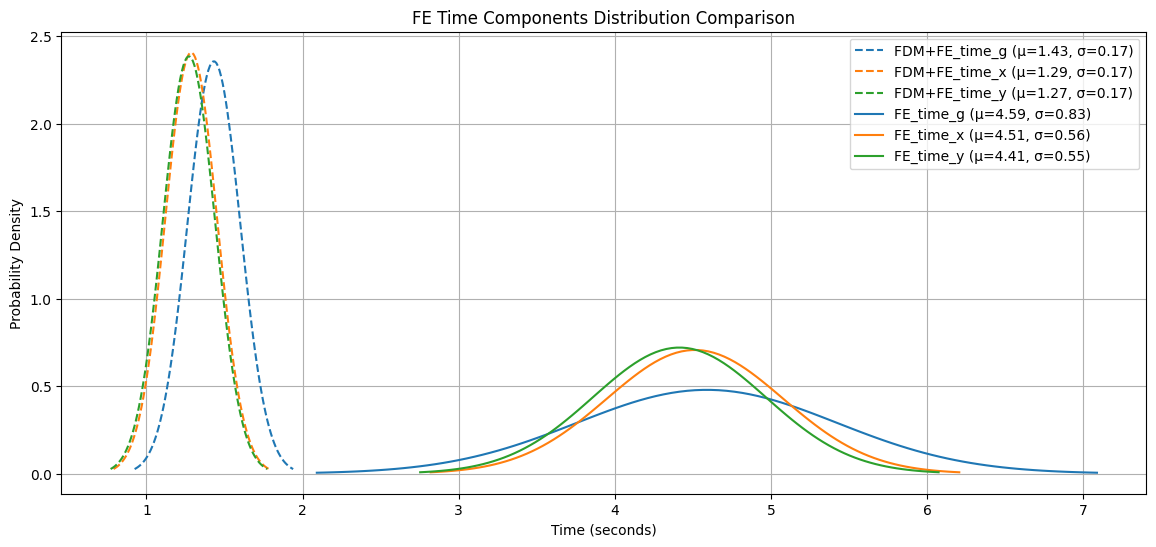

FDM+FE方法各组件时间排序（Top 5）：
FE_time_g:
  最长5次迭代: [4, 0, 259, 134, 49]
  对应时间: [2.3602235317230225, 2.1013050079345703, 2.0878400802612305, 2.045515537261963, 2.0418412685394287]
FE_time_x:
  最长5次迭代: [48, 121, 117, 197, 9]
  对应时间: [1.8747897148132324, 1.870100975036621, 1.8182597160339355, 1.8162193298339844, 1.7977263927459717]
FE_time_y:
  最长5次迭代: [40, 190, 405, 35, 31]
  对应时间: [2.0547287464141846, 1.960214614868164, 1.882134199142456, 1.849611759185791, 1.8450331687927246]

纯FE方法各组件时间排序（Top 5）：
FE_time_g:
  最长5次迭代: [18, 31, 14, 253, 6]
  对应时间: [16.623398065567017, 7.662782907485962, 7.195805072784424, 6.783440828323364, 6.635470867156982]
FE_time_x:
  最长5次迭代: [18, 31, 242, 253, 14]
  对应时间: [8.882760047912598, 6.726109027862549, 6.53233790397644, 6.465763807296753, 6.280017137527466]
FE_time_y:
  最长5次迭代: [18, 459, 14, 284, 1]
  对应时间: [9.288823127746582, 7.521938323974609, 6.793225049972534, 6.604748010635376, 6.326236009597778]


In [5]:
import json
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# 加载数据
def load_fe_times(filename):
    with open(filename) as f:
        data = json.load(f)
    return {
        'g': [it['timing']['FE_time_g'] for it in data['iterations']],
        'x': [it['timing']['FE_time_x'] for it in data['iterations']],
        'y': [it['timing']['FE_time_y'] for it in data['iterations']],
        'iterations': [it['iteration'] for it in data['iterations']]
    }

fdm_data = load_fe_times('Moo_time.json')
fem_data = load_fe_times('FEMoo_time.json')


plt.figure(figsize=(14, 6))

# 绘制FDM+FE数据分布
for i, (key, color) in enumerate(zip(['g', 'x', 'y'], ['#1f77b4', '#ff7f0e', '#2ca02c'])):
    data = fdm_data[key]
    mu, std = np.mean(data), np.std(data)
    x = np.linspace(mu-3*std, mu+3*std, 100)
    plt.plot(x, norm.pdf(x, mu, std), 
             label=f'FDM+FE_time_{key} (μ={mu:.2f}, σ={std:.2f})',
             color=color, linestyle='--')

# 绘制纯FE数据分布
for i, (key, color) in enumerate(zip(['g', 'x', 'y'], ['#1f77b4', '#ff7f0e', '#2ca02c'])):
    data = fem_data[key]
    mu, std = np.mean(data), np.std(data)
    x = np.linspace(mu-3*std, mu+3*std, 100)
    plt.plot(x, norm.pdf(x, mu, std), 
             label=f'FE_time_{key} (μ={mu:.2f}, σ={std:.2f})',
             color=color)

plt.title('FE Time Components Distribution Comparison')
plt.xlabel('Time (seconds)')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(True)
plt.show()

# 生成排序后的迭代编号
def get_sorted_iterations(times, iterations):
    return [i for _, i in sorted(zip(times, iterations), reverse=True)]

# FDM+FE数据排序结果
print("FDM+FE方法各组件时间排序（Top 5）：")
for comp in ['g', 'x', 'y']:
    sorted_iter = get_sorted_iterations(fdm_data[comp], fdm_data['iterations'])
    print(f"FE_time_{comp}:")
    print(f"  最长5次迭代: {sorted_iter[:5]}")
    print(f"  对应时间: {[fdm_data[comp][i] for i in sorted_iter[:5]]}")

# 纯FE数据排序结果
print("\n纯FE方法各组件时间排序（Top 5）：")
for comp in ['g', 'x', 'y']:
    sorted_iter = get_sorted_iterations(fem_data[comp], fem_data['iterations'])
    print(f"FE_time_{comp}:")
    print(f"  最长5次迭代: {sorted_iter[:5]}")
    print(f"  对应时间: {[fem_data[comp][i] for i in sorted_iter[:5]]}")

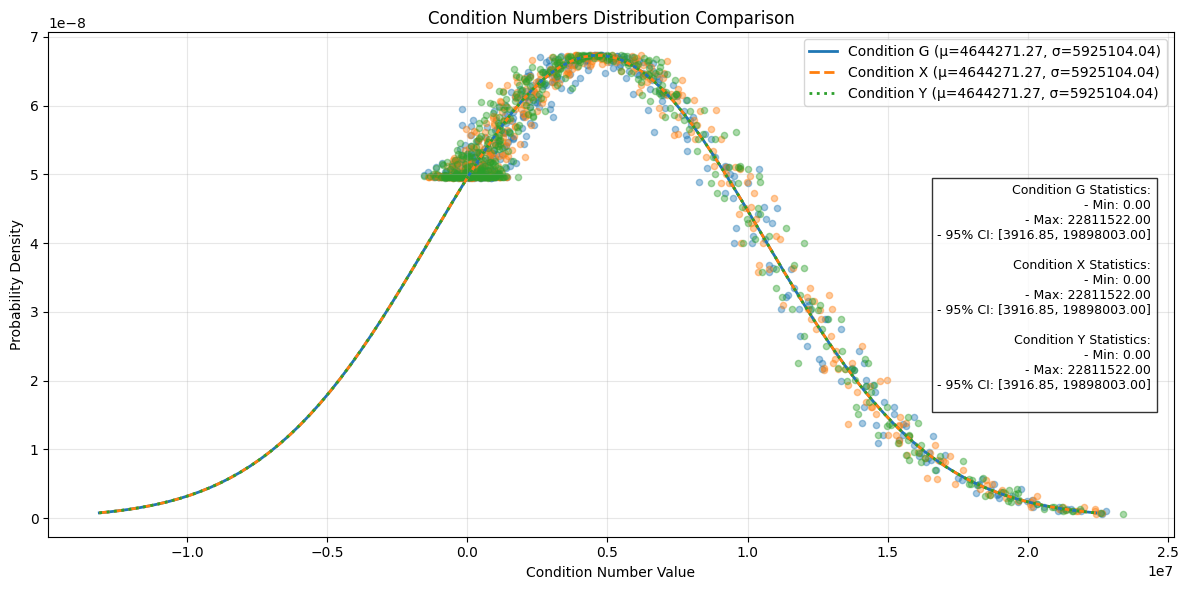

In [6]:
import json
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# 加载数据函数
def load_conditions(filename):
    with open(filename) as f:
        data = json.load(f)
    return {
        'condition_g': [it['condition_g'] for it in data['iterations']],
        'condition_x': [it['condition_x'] for it in data['iterations']],
        'condition_y': [it['condition_y'] for it in data['iterations']],
        'iterations': [it['iteration'] for it in data['iterations']]
    }

# 加载数据
data = load_conditions('Moo_condi.json')  # 请替换为实际文件名

# 创建画布
plt.figure(figsize=(12, 6))

# 颜色和线型设置
styles = [
    {'color': '#1f77b4', 'linestyle': '-', 'label': 'Condition G'},
    {'color': '#ff7f0e', 'linestyle': '--', 'label': 'Condition X'},
    {'color': '#2ca02c', 'linestyle': ':', 'label': 'Condition Y'}
]

# 绘制三个条件的分布
stats_text = []
for idx, cond_name in enumerate(['condition_g', 'condition_x', 'condition_y']):
    cond_data = data[cond_name]
    mu, std = np.mean(cond_data), np.std(cond_data)
    x = np.linspace(mu-3*std, mu+3*std, 100)
    
    # 绘制正态分布曲线
    plt.plot(x, norm.pdf(x, mu, std),
             label=f'{styles[idx]["label"]} (μ={mu:.2f}, σ={std:.2f})',
             color=styles[idx]['color'],
             linestyle=styles[idx]['linestyle'],
             linewidth=2)
    
    # 绘制原始数据点（添加抖动避免重叠）
    jitter = std * 0.1 * np.random.randn(len(cond_data))
    plt.scatter(cond_data + jitter, 
                norm.pdf(cond_data, mu, std),
                color=styles[idx]['color'],
                alpha=0.4,
                s=20)
    
    # 收集统计信息
    stats_text.extend([
        f"{styles[idx]['label']} Statistics:",
        f"- Min: {np.min(cond_data):.2f}",
        f"- Max: {np.max(cond_data):.2f}",
        f"- 95% CI: [{np.percentile(cond_data, 2.5):.2f}, {np.percentile(cond_data, 97.5):.2f}]",
        ""  # 空行分隔
    ])

# 图表装饰
plt.title('Condition Numbers Distribution Comparison')
plt.xlabel('Condition Number Value')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

# 添加统计信息框
plt.text(0.98, 0.70, "\n".join(stats_text), transform=plt.gca().transAxes,
         ha='right', va='top', bbox=dict(facecolor='white', alpha=0.8),
         fontsize=9)

plt.show()

FDM+FE数据中的timing组件: ['Geometry_init', 'FDM', 'Loss', 'Backprop', 'Param_update']


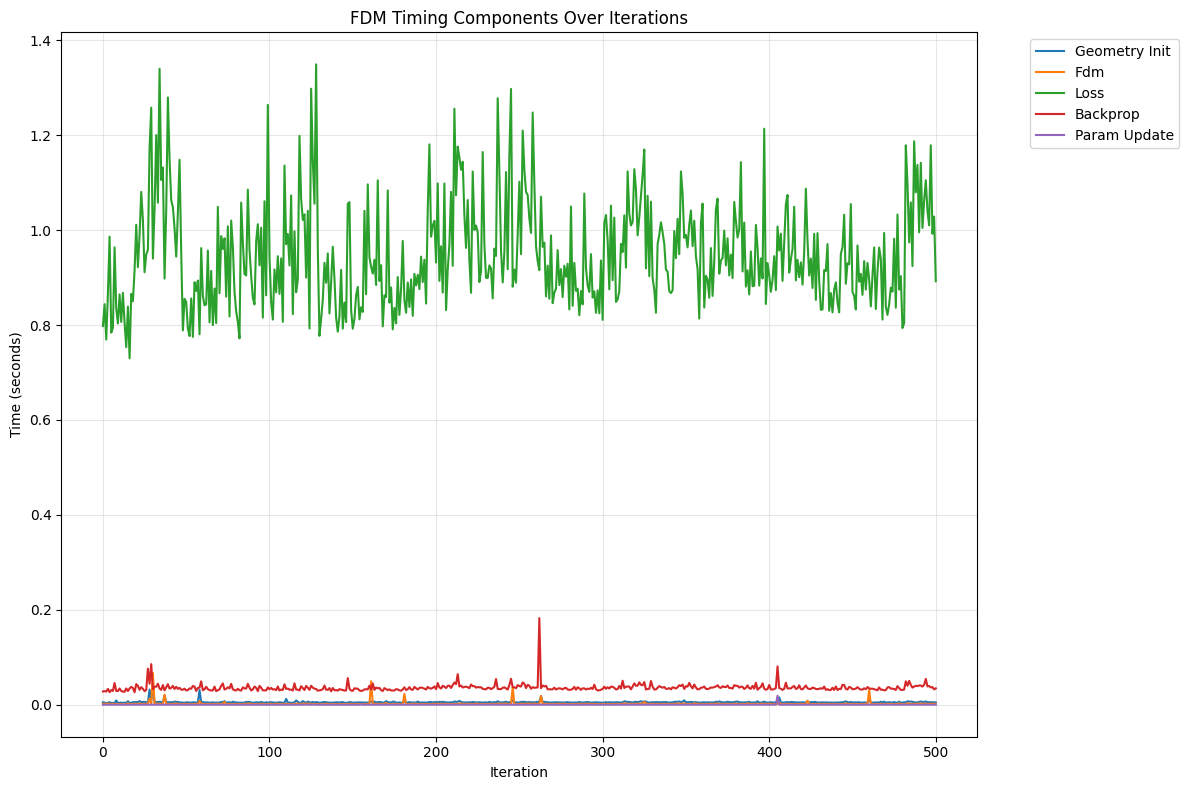

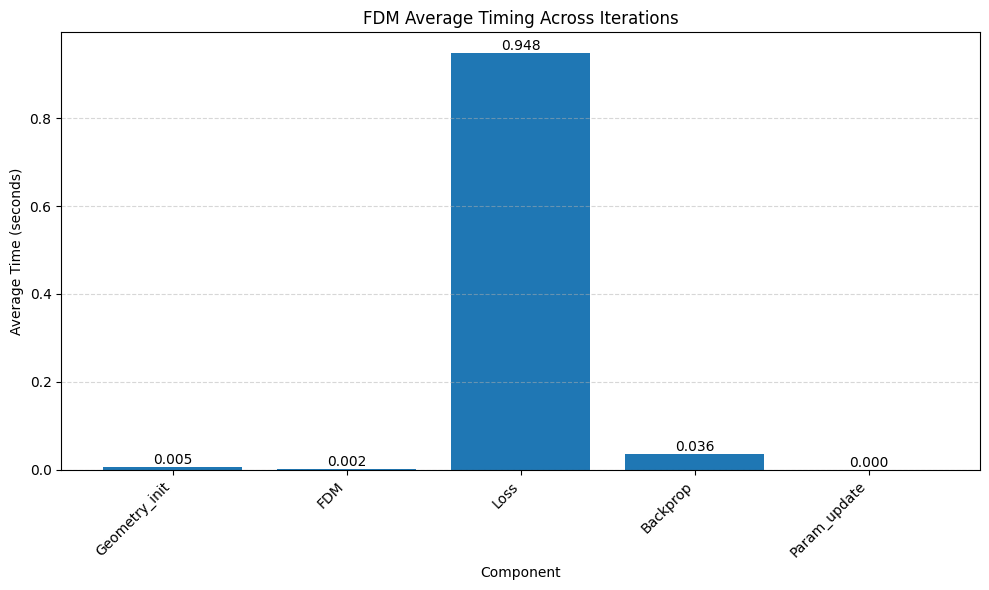

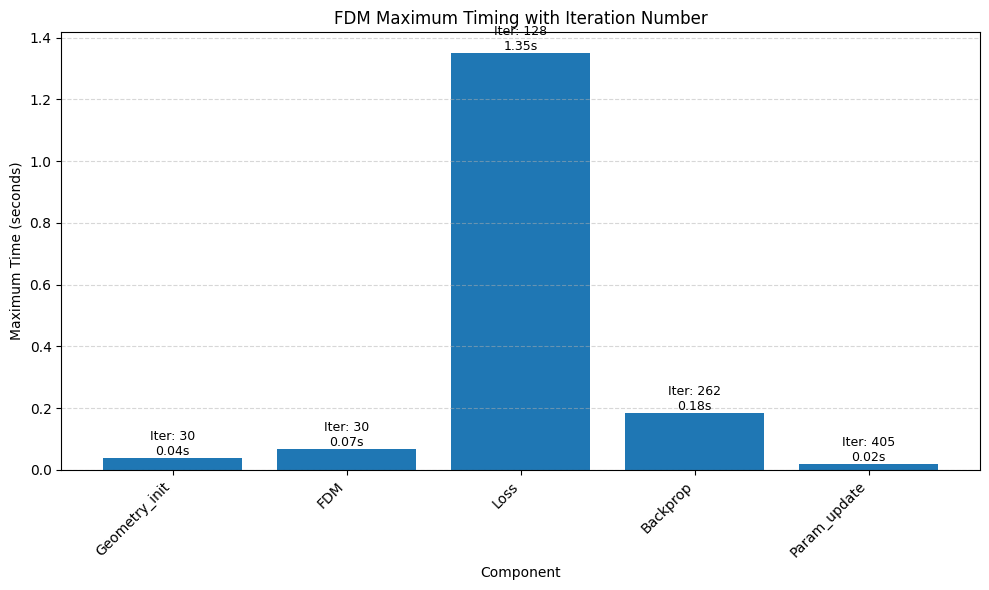

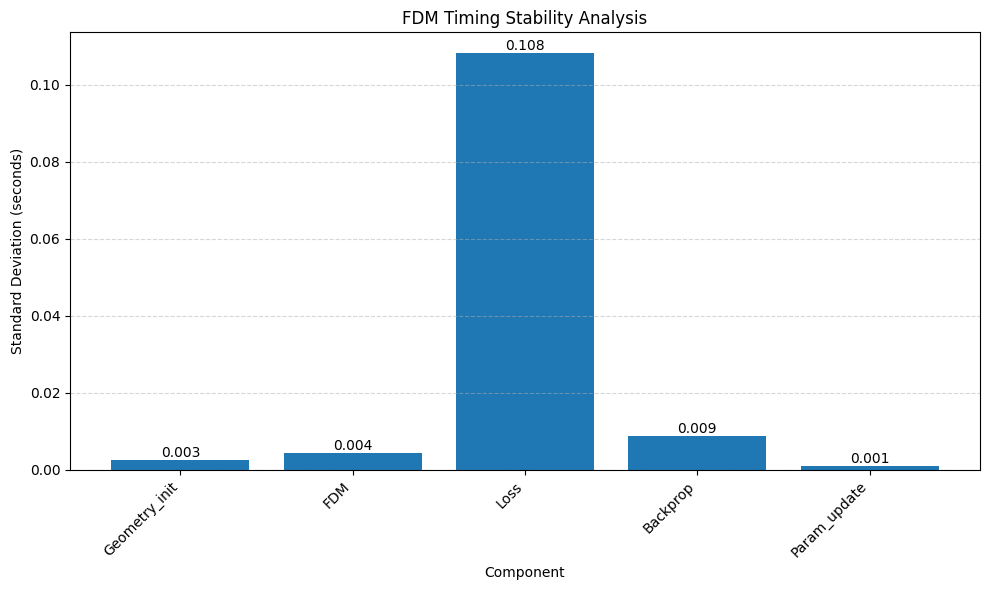

In [7]:
import json
import matplotlib.pyplot as plt
import numpy as np

# 加载FDM+FE数据
with open('FDM_time.json') as f:
    data_fdm = json.load(f)

# 提取timing数据并统一键名（处理可能的空格问题）
timings_fdm = []
for iteration in data_fdm['iterations']:
    timing = {
        'Geometry_init': iteration.get('Geometry_initialization_time', 0),
        'FDM': iteration.get('FDM_time', 0),
        'Loss': iteration.get('Loss_time', 0),
        'Backprop': iteration.get('Back_time ', 0),  # 注意处理键名中的空格
        'Param_update': iteration.get('Parameter_update', 0)
    }
    timings_fdm.append(timing)

components_fdm = list(timings_fdm[0].keys())
print("FDM+FE数据中的timing组件:", components_fdm)

# ====================== 1. 各组件时间随迭代变化 ======================
plt.figure(figsize=(12, 8))
for comp in components_fdm:
    plt.plot(range(len(timings_fdm)), [t[comp] for t in timings_fdm], 
             label=comp.replace('_', ' ').title())
plt.xlabel('Iteration')
plt.ylabel('Time (seconds)')
plt.title('FDM Timing Components Over Iterations')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ====================== 2. 平均时间柱状图 ======================
avg_fdm = {comp: np.mean([t[comp] for t in timings_fdm]) for comp in components_fdm}

plt.figure(figsize=(10, 6))
bars = plt.bar(avg_fdm.keys(), avg_fdm.values())
plt.xlabel('Component')
plt.ylabel('Average Time (seconds)')
plt.title('FDM Average Timing Across Iterations')
plt.xticks(rotation=45, ha='right')

# 添加数值标签
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, 
             f'{height:.3f}', ha='center', va='bottom')

plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# ====================== 3. 最大时间及对应迭代 ======================
max_fdm = {}
max_iter_fdm = {}
for comp in components_fdm:
    values = [t[comp] for t in timings_fdm]
    max_fdm[comp] = max(values)
    max_iter_fdm[comp] = values.index(max(values))

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(max_fdm.keys(), max_fdm.values())
ax.set_xlabel('Component')
ax.set_ylabel('Maximum Time (seconds)')
ax.set_title('FDM Maximum Timing with Iteration Number')
plt.xticks(rotation=45, ha='right')

# 添加双行标注
for bar, comp in zip(bars, components_fdm):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height,
            f'Iter: {max_iter_fdm[comp]}\n{height:.2f}s',
            ha='center', va='bottom', fontsize=9)

plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# ====================== 4. 标准差分析 ======================
std_fdm = {comp: np.std([t[comp] for t in timings_fdm]) for comp in components_fdm}

plt.figure(figsize=(10, 6))
bars = plt.bar(std_fdm.keys(), std_fdm.values())
plt.xlabel('Component')
plt.ylabel('Standard Deviation (seconds)')
plt.title('FDM Timing Stability Analysis')
plt.xticks(rotation=45, ha='right')

# 添加数值标签
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, 
             f'{height:.3f}', ha='center', va='bottom')

plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

FE数据中的timing组件: ['Geometry_ini', 'FE_time_g', 'FE_time_x', 'FE_time_y', 'Earlystopping', 'Back_propagation time', 'ParametersUpgrade']


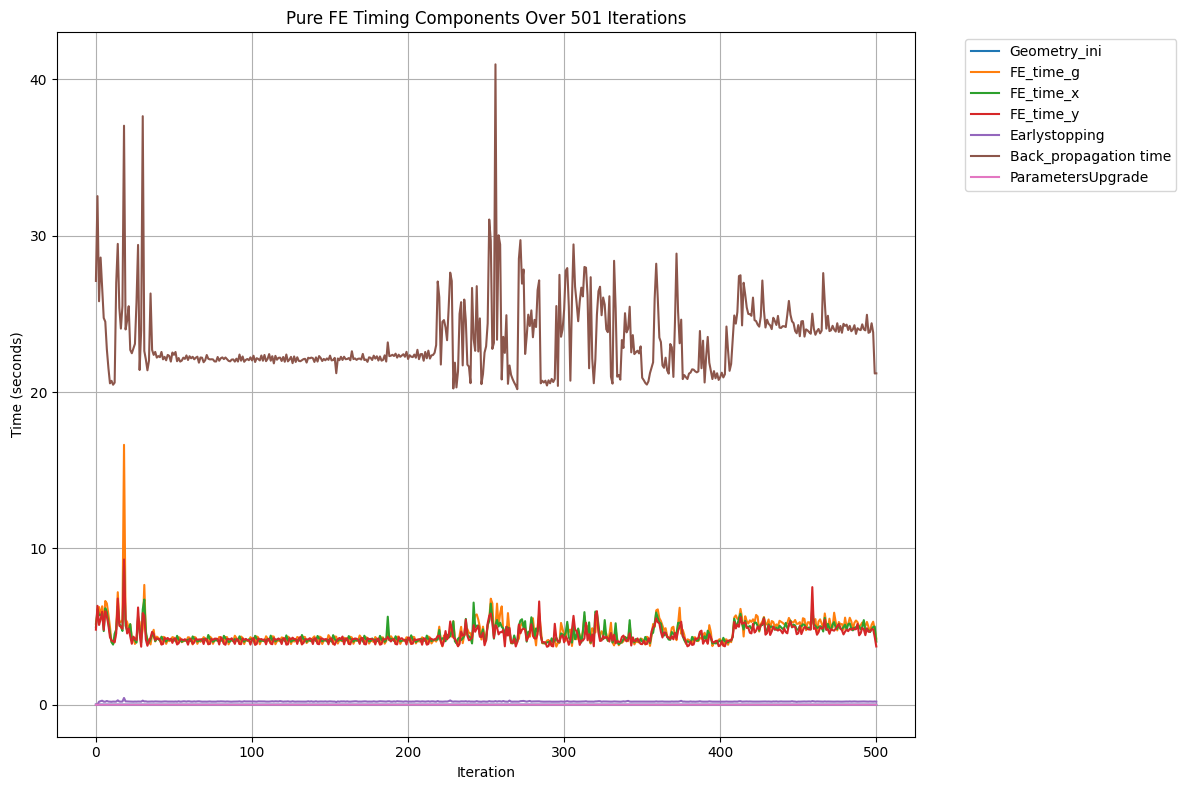

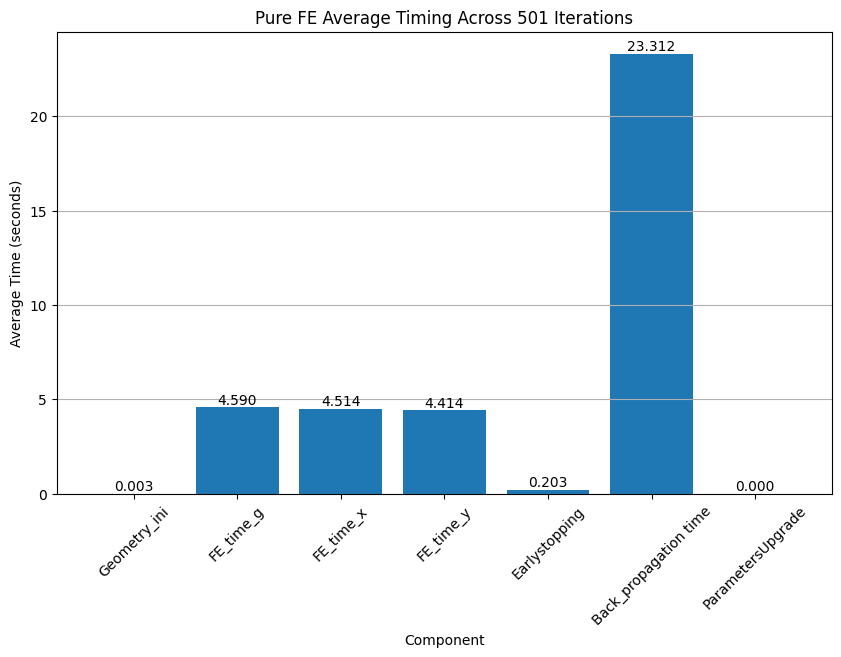

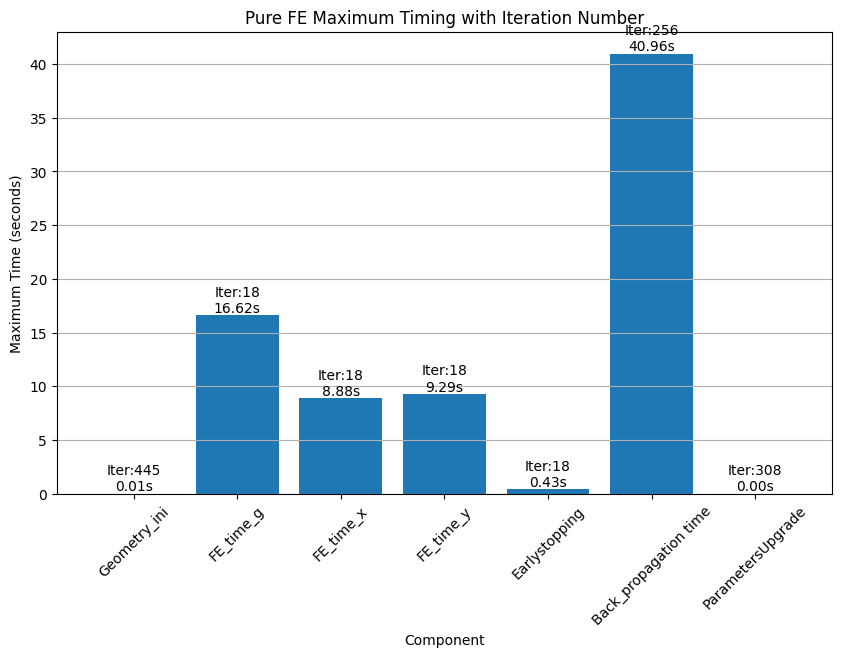

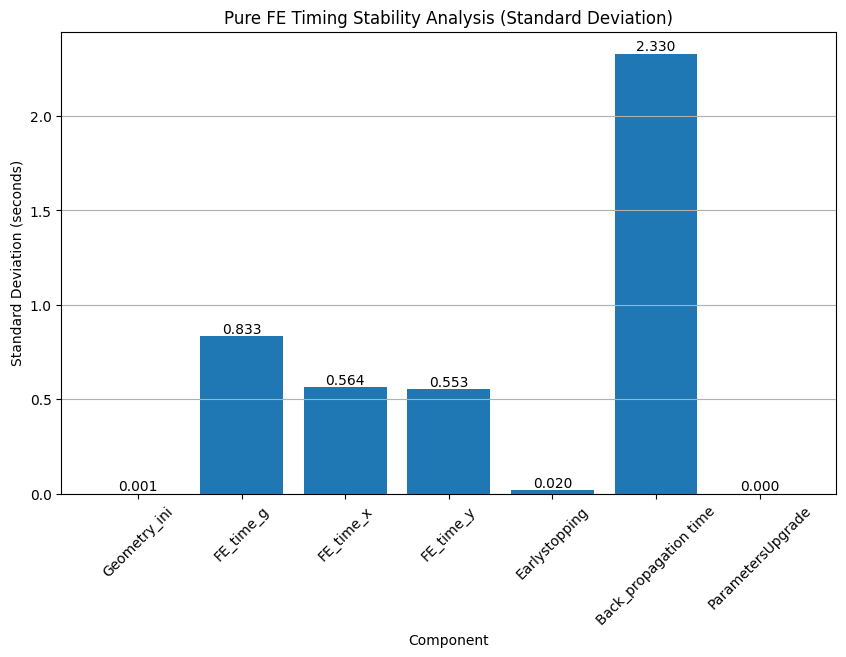

In [8]:
import json
import matplotlib.pyplot as plt
import numpy as np

# 加载FE-only数据
with open('FEMoo_time.json') as f:
    data_fem = json.load(f)

# 提取timing数据
timings_fem = [iteration['timing'] for iteration in data_fem['iterations']]
components_fem = list(timings_fem[0].keys())  # 自动获取实际存在的组件
print("FE数据中的timing组件:", components_fem)

plt.figure(figsize=(12, 8))
for comp in components_fem:
    plt.plot(range(501), [t[comp] for t in timings_fem], label=comp)
plt.xlabel('Iteration')
plt.ylabel('Time (seconds)')
plt.title('Pure FE Timing Components Over 501 Iterations')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()


# 计算平均值
avg_fem = {comp: np.mean([t[comp] for t in timings_fem]) for comp in components_fem}

# 绘制柱状图
plt.figure(figsize=(10, 6))
plt.bar(components_fem, avg_fem.values())
plt.xlabel('Component')
plt.ylabel('Average Time (seconds)')
plt.title('Pure FE Average Timing Across 501 Iterations')
plt.xticks(rotation=45)
plt.grid(True, axis='y')

# 添加数值标签
for i, (comp, val) in enumerate(avg_fem.items()):
    plt.text(i, val, f'{val:.3f}', ha='center', va='bottom')

plt.show()


# 找出最大值及对应迭代
max_fem = {}
max_iter_fem = {}
for comp in components_fem:
    values = [t[comp] for t in timings_fem]
    max_fem[comp] = max(values)
    max_iter_fem[comp] = values.index(max(values))

# 绘制最大时间柱状图
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(components_fem, max_fem.values())
ax.set_xlabel('Component')
ax.set_ylabel('Maximum Time (seconds)')
ax.set_title('Pure FE Maximum Timing with Iteration Number')
ax.grid(True, axis='y')

# 添加标注
for bar, comp in zip(bars, components_fem):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height,
            f'Iter:{max_iter_fem[comp]}\n{height:.2f}s',
            ha='center', va='bottom')

plt.xticks(rotation=45)
plt.show()

# 计算标准差
std_fem = {comp: np.std([t[comp] for t in timings_fem]) for comp in components_fem}

# 绘制标准差柱状图
plt.figure(figsize=(10, 6))
plt.bar(components_fem, std_fem.values())
plt.xlabel('Component')
plt.ylabel('Standard Deviation (seconds)')
plt.title('Pure FE Timing Stability Analysis (Standard Deviation)')
plt.xticks(rotation=45)
plt.grid(True, axis='y')

# 添加数值标签
for i, (comp, val) in enumerate(std_fem.items()):
    plt.text(i, val, f'{val:.3f}', ha='center', va='bottom')

plt.show()

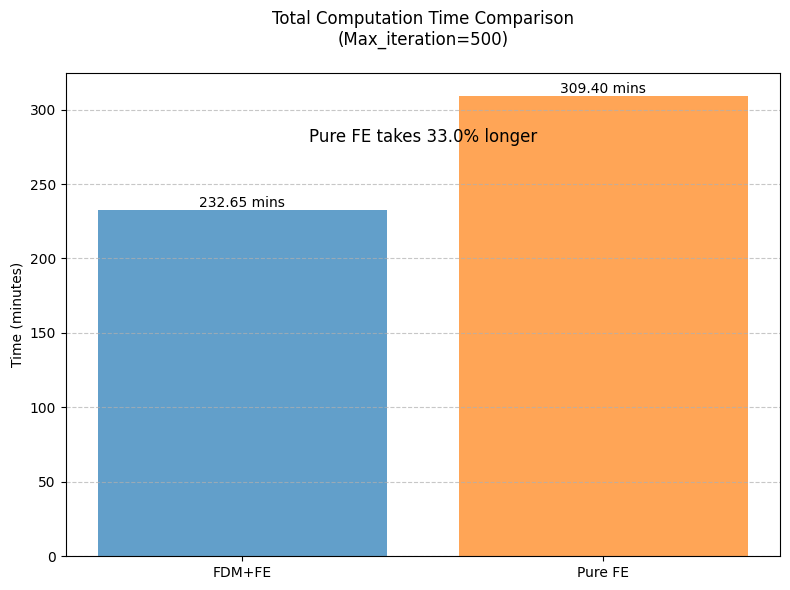

In [9]:
import json
import matplotlib.pyplot as plt

# 加载数据
def load_ite_time(filename):
    with open(filename) as f:
        data = json.load(f)
    return data['metadata']['Ite_time']  # 转换为分钟

# 获取两种方法的总时间
fdm_time = load_ite_time('Moo_time.json')  # FDM+FE方法
fem_time = load_ite_time('FEMoo_time.json')  # 纯FE方法

# 准备对比数据
methods = ['FDM+FE', 'Pure FE']
times = [fdm_time, fem_time]
colors = ['#1f77b4', '#ff7f0e']
plt.figure(figsize=(8, 6))
bars = plt.bar(methods, times, color=colors, alpha=0.7)

# 添加数值标签和单位
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f} mins',
            ha='center', va='bottom')

# 添加说明文字
plt.title('Total Computation Time Comparison\n(Max_iteration=500)', pad=20)
plt.ylabel('Time (minutes)')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

# 显示差异百分比
diff_percent = (fem_time - fdm_time) / fdm_time * 100
plt.text(0.5, max(times)*0.9, 
        f'Pure FE takes {diff_percent:.1f}% longer',
        ha='center', fontsize=12)

plt.tight_layout()
plt.show()

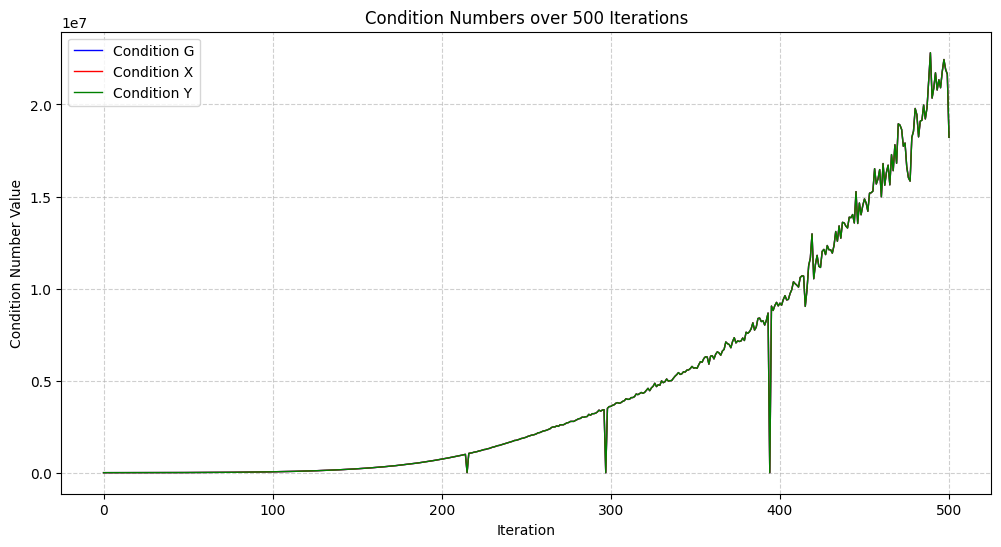

In [10]:
import json
import matplotlib.pyplot as plt
import pandas as pd

# 1. 读取JSON文件
with open('Moo_condi.json', 'r') as f:
    data = json.load(f)

# 2. 提取数据
iterations = data['iterations']
df = pd.DataFrame({
    'iteration': [entry['iteration'] for entry in iterations],
    'condition_g': [entry['condition_g'] for entry in iterations],
    'condition_x': [entry['condition_x'] for entry in iterations],
    'condition_y': [entry['condition_y'] for entry in iterations]
})

# 3. 绘制三条曲线（直接按迭代顺序）
plt.figure(figsize=(12, 6))
plt.plot(df['iteration'], df['condition_g'], label='Condition G', color='blue', linewidth=1)
plt.plot(df['iteration'], df['condition_x'], label='Condition X', color='red', linewidth=1)
plt.plot(df['iteration'], df['condition_y'], label='Condition Y', color='green', linewidth=1)

# 4. 添加图例和标签
plt.title('Condition Numbers over 500 Iterations')
plt.xlabel('Iteration')
plt.ylabel('Condition Number Value')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

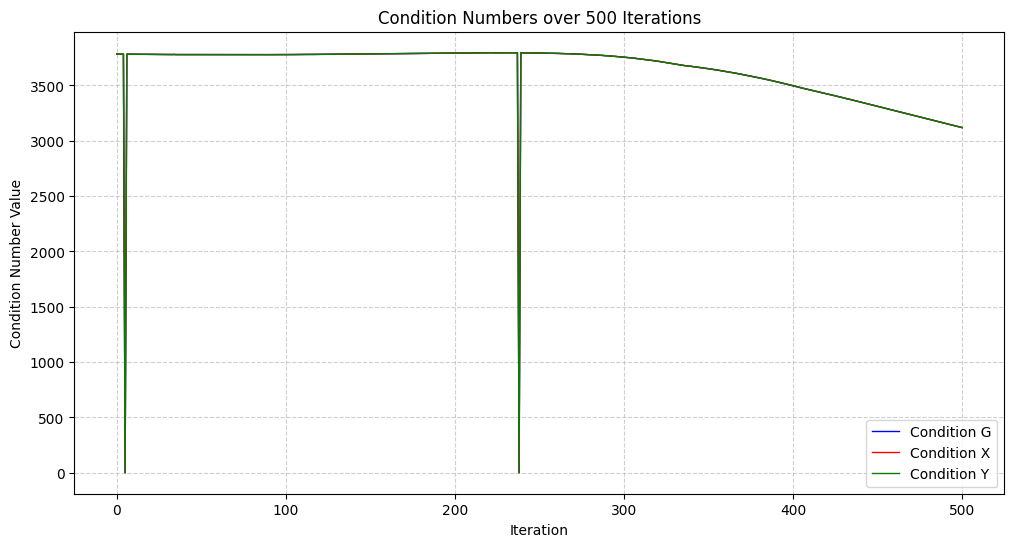

In [11]:
import json
import matplotlib.pyplot as plt
import pandas as pd

# 1. 读取JSON文件
with open('FE_condi.json', 'r') as f:
    data = json.load(f)

# 2. 提取数据
iterations = data['iterations']
df = pd.DataFrame({
    'iteration': [entry['iteration'] for entry in iterations],
    'condition_g': [entry['condition_g'] for entry in iterations],
    'condition_x': [entry['condition_x'] for entry in iterations],
    'condition_y': [entry['condition_y'] for entry in iterations]
})

# 3. 绘制三条曲线（直接按迭代顺序）
plt.figure(figsize=(12, 6))
plt.plot(df['iteration'], df['condition_g'], label='Condition G', color='blue', linewidth=1)
plt.plot(df['iteration'], df['condition_x'], label='Condition X', color='red', linewidth=1)
plt.plot(df['iteration'], df['condition_y'], label='Condition Y', color='green', linewidth=1)

# 4. 添加图例和标签
plt.title('Condition Numbers over 500 Iterations')
plt.xlabel('Iteration')
plt.ylabel('Condition Number Value')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

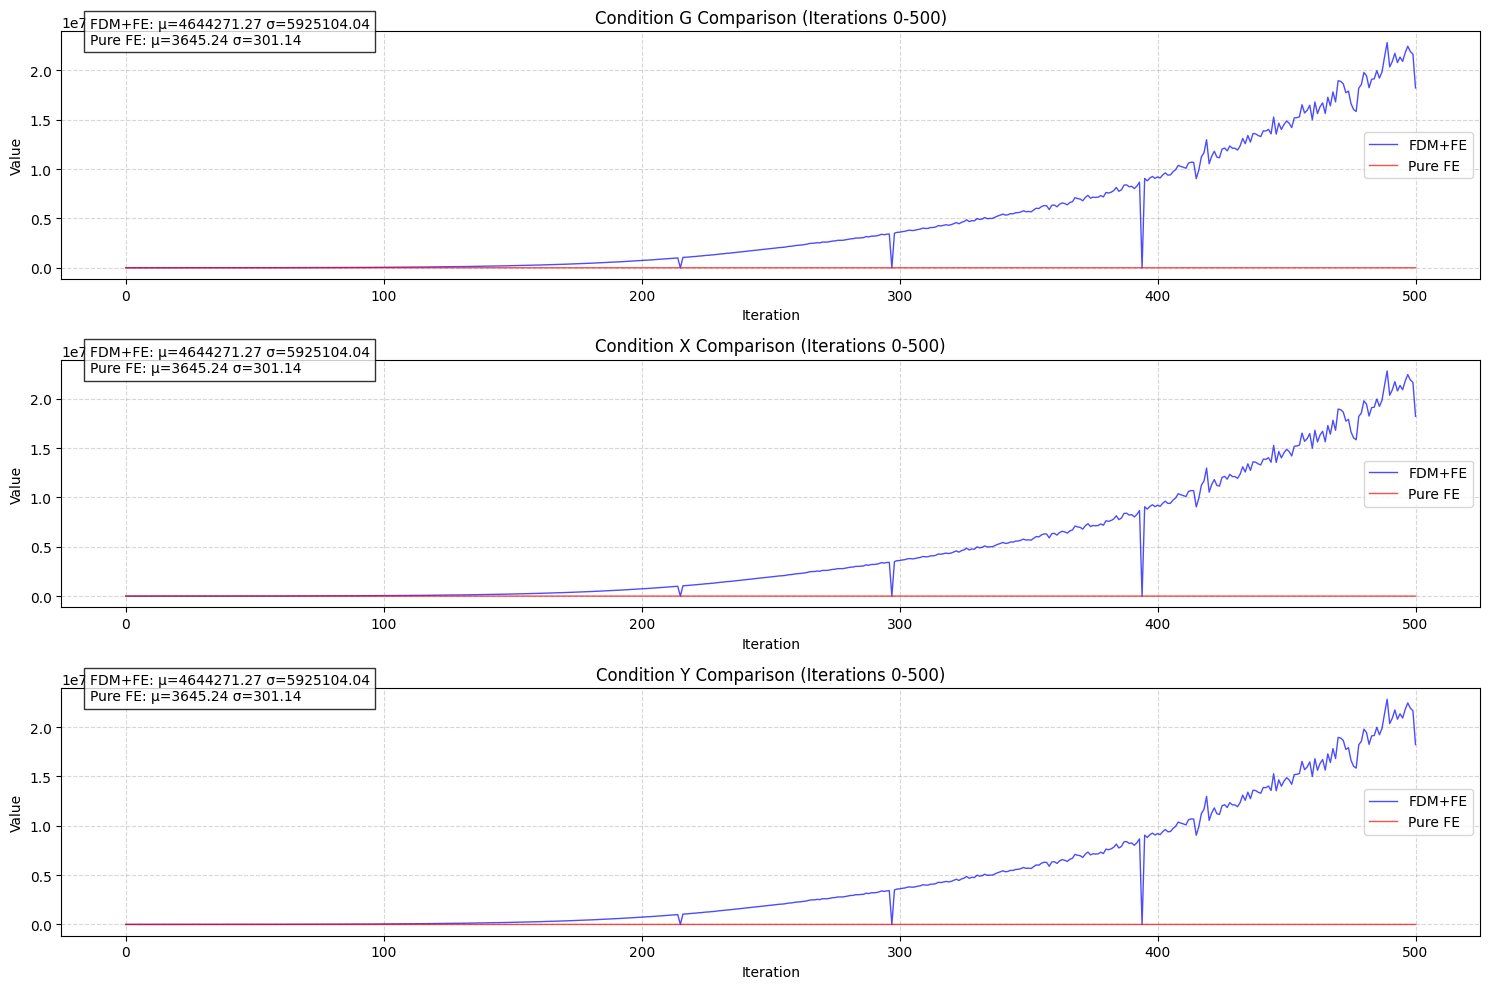

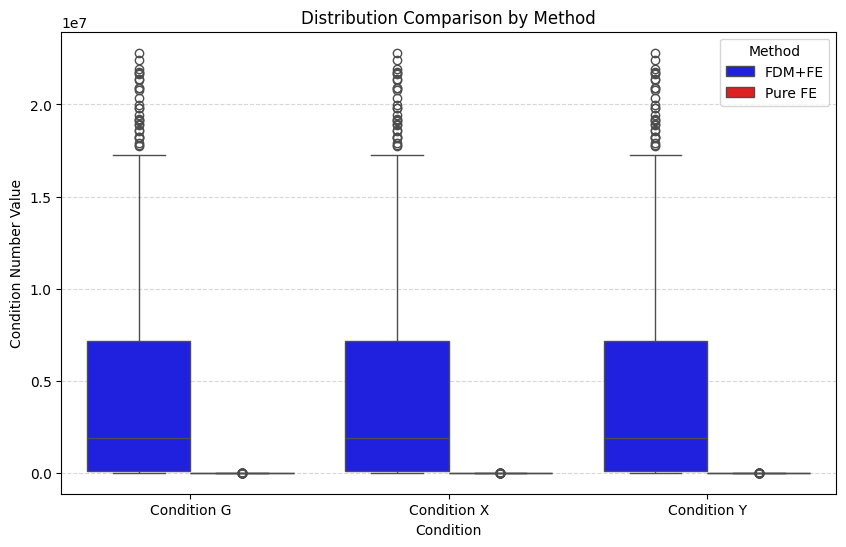

In [12]:
import json
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def load_conditions(filename):
    """加载JSON文件中的condition数据"""
    with open(filename) as f:
        data = json.load(f)
    return {
        'iteration': [it['iteration'] for it in data['iterations']],
        'condition_g': [it['condition_g'] for it in data['iterations']],
        'condition_x': [it['condition_x'] for it in data['iterations']],
        'condition_y': [it['condition_y'] for it in data['iterations']]
    }

# 加载两个数据集
moo_data = load_conditions('Moo_condi.json')
fe_data = load_conditions('FE_condi.json')

# 创建对比图（3个子图，每个condition一个）
plt.figure(figsize=(15, 10))

# 为每个condition创建子图
conditions = ['condition_g', 'condition_x', 'condition_y']
titles = ['Condition G', 'Condition X', 'Condition Y']

for i, (cond, title) in enumerate(zip(conditions, titles)):
    plt.subplot(3, 1, i+1)
    
    # 绘制Moo数据
    plt.plot(moo_data['iteration'], moo_data[cond], 
             label='FDM+FE', color='blue', alpha=0.7, linewidth=1)
    
    # 绘制FE数据
    plt.plot(fe_data['iteration'], fe_data[cond], 
             label='Pure FE', color='red', alpha=0.7, linewidth=1)
    
    # 图表装饰
    plt.title(f'{title} Comparison (Iterations 0-500)')
    plt.xlabel('Iteration')
    plt.ylabel('Value')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    
    # 添加统计信息
    plt.text(0.02, 0.95, 
             f"FDM+FE: μ={np.mean(moo_data[cond]):.2f} σ={np.std(moo_data[cond]):.2f}\n"
             f"Pure FE: μ={np.mean(fe_data[cond]):.2f} σ={np.std(fe_data[cond]):.2f}",
             transform=plt.gca().transAxes,
             bbox=dict(facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

# 箱线图对比
plt.figure(figsize=(10, 6))
df_compare = pd.DataFrame({
    'Method': ['FDM+FE']*501 + ['Pure FE']*501,
    'Condition G': moo_data['condition_g'] + fe_data['condition_g'],
    'Condition X': moo_data['condition_x'] + fe_data['condition_x'],
    'Condition Y': moo_data['condition_y'] + fe_data['condition_y']
})

# 熔化数据以便seaborn使用
df_melted = df_compare.melt(id_vars=['Method'], 
                            value_vars=['Condition G', 'Condition X', 'Condition Y'],
                            var_name='Condition',
                            value_name='Value')

# 绘制箱线图
import seaborn as sns
sns.boxplot(x='Condition', y='Value', hue='Method', data=df_melted, palette={'FDM+FE': 'blue', 'Pure FE': 'red'})
plt.title('Distribution Comparison by Method')
plt.ylabel('Condition Number Value')
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.show()

FDM+FE 文件统计结果:
condition_g: 零值总数 = 5
    出现代数: [10, 16, 215, 297, 394]
----------------------------------------
condition_x: 零值总数 = 5
    出现代数: [10, 16, 215, 297, 394]
----------------------------------------
condition_y: 零值总数 = 5
    出现代数: [10, 16, 215, 297, 394]
----------------------------------------

Pure FE 文件统计结果:
condition_g: 零值总数 = 2
    出现代数: [5, 238]
----------------------------------------
condition_x: 零值总数 = 2
    出现代数: [5, 238]
----------------------------------------
condition_y: 零值总数 = 2
    出现代数: [5, 238]
----------------------------------------


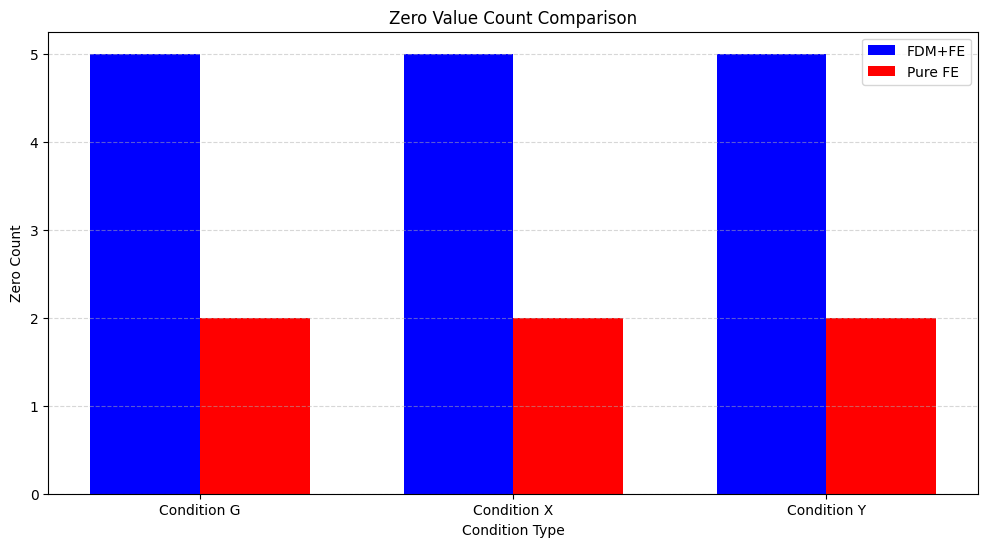

In [13]:
import json

def find_zero_conditions(filename):
    """统计指定文件中各condition为零的迭代次数和具体代数"""
    with open(filename) as f:
        data = json.load(f)
    
    zero_counts = {'condition_g': 0, 'condition_x': 0, 'condition_y': 0}
    zero_iterations = {'condition_g': [], 'condition_x': [], 'condition_y': []}
    
    for entry in data['iterations']:
        for cond in zero_counts.keys():
            if abs(entry[cond]) < 1e-6:  # 考虑浮点精度误差
                zero_counts[cond] += 1
                zero_iterations[cond].append(entry['iteration'])
    
    return zero_counts, zero_iterations

# 统计两个文件
moo_counts, moo_iters = find_zero_conditions('Moo_condi.json')
fe_counts, fe_iters = find_zero_conditions('FE_condi.json')

# 打印结果
print("="*50)
print("FDM+FE 文件统计结果:")
for cond in moo_counts:
    print(f"{cond}: 零值总数 = {moo_counts[cond]}")
    print(f"    出现代数: {moo_iters[cond]}")
    print("-"*40)

print("\n" + "="*50)
print("Pure FE 文件统计结果:")
for cond in fe_counts:
    print(f"{cond}: 零值总数 = {fe_counts[cond]}")
    print(f"    出现代数: {fe_iters[cond]}")
    print("-"*40)

# 可视化对比
import matplotlib.pyplot as plt

conditions = ['condition_g', 'condition_x', 'condition_y']
labels = ['Condition G', 'Condition X', 'Condition Y']

plt.figure(figsize=(12, 6))
x = range(len(conditions))
width = 0.35

plt.bar(x, [moo_counts[c] for c in conditions], width, label='FDM+FE', color='blue')
plt.bar([i + width for i in x], [fe_counts[c] for c in conditions], width, label='Pure FE', color='red')

plt.xlabel('Condition Type')
plt.ylabel('Zero Count')
plt.title('Zero Value Count Comparison')
plt.xticks([i + width/2 for i in x], labels)
plt.legend()
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.show()

FE组件: ['Backpropagation_time', 'Geometry Initialization_time', 'FE_time', 'Parametric Update', 'Loss cal_time']
FDM组件: ['FDM_time', 'Backpropagation_time', 'Geometry Initialization_time', 'FE_time', 'Parametric Update', 'Loss cal_time']
共同组件: ['Backpropagation_time', 'FE_time', 'Geometry Initialization_time', 'Loss cal_time', 'Parametric Update']


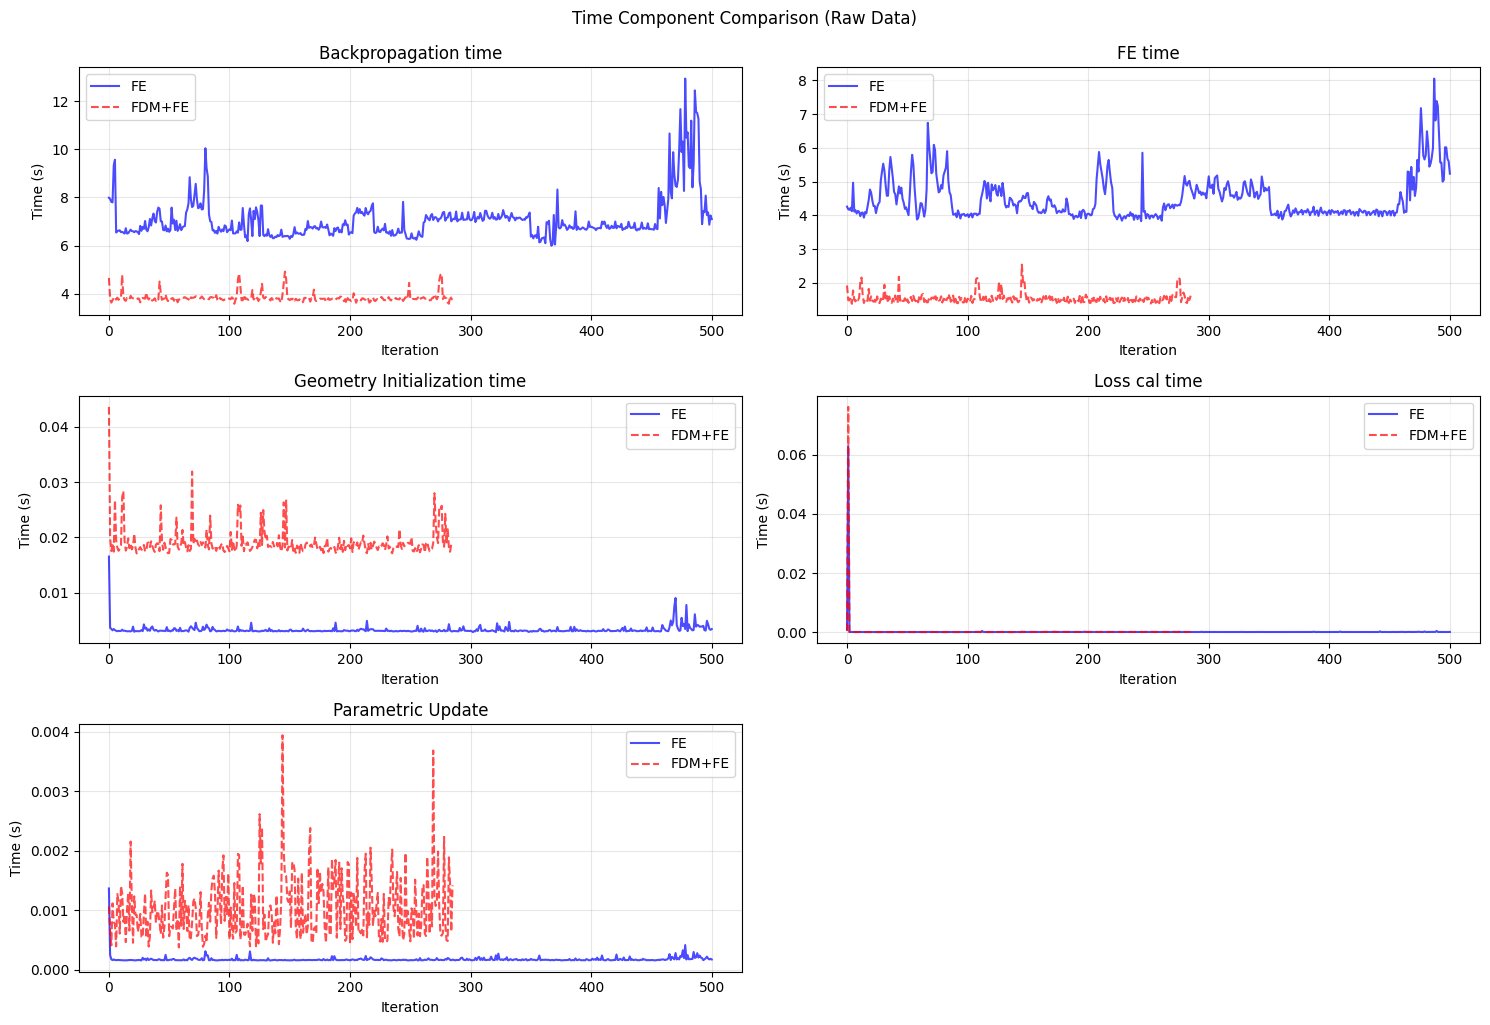

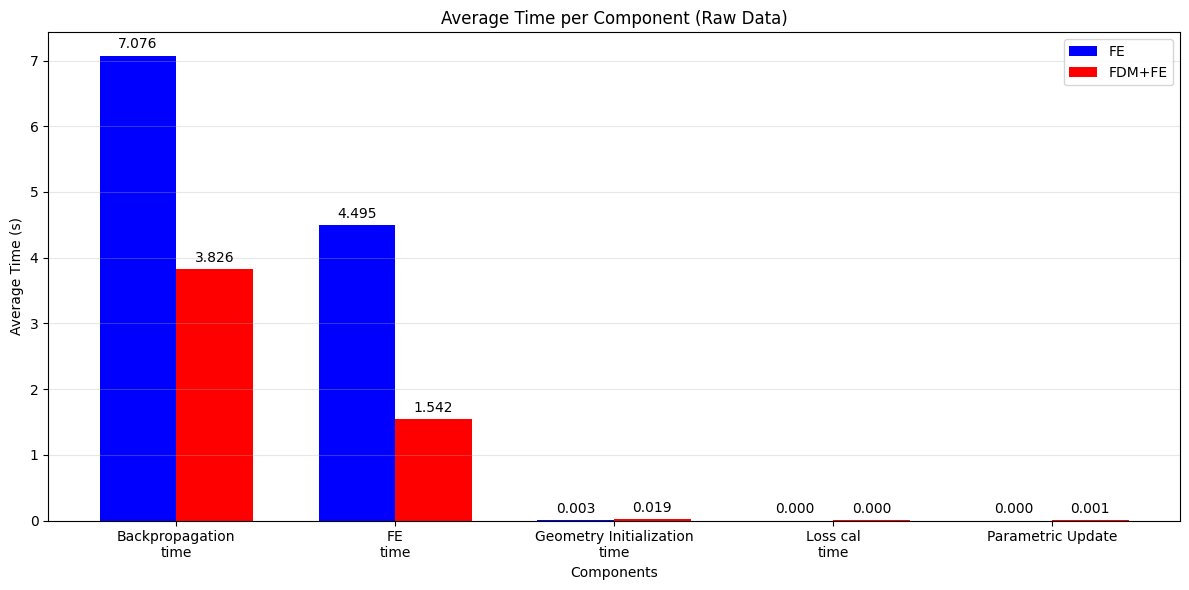

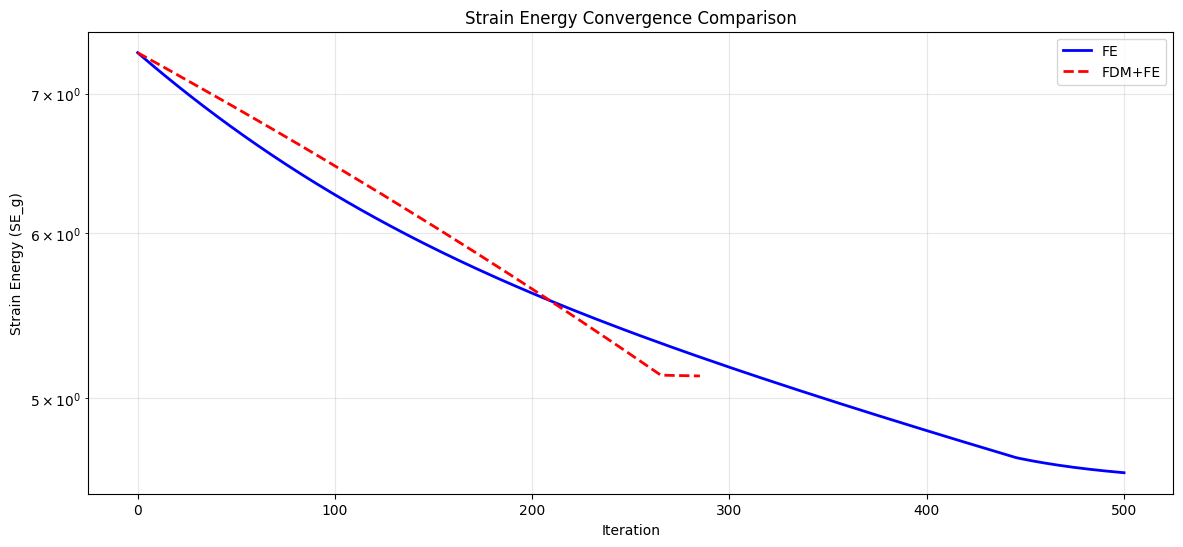


性能总结:
指标                                     FE          FDM+FE         提升
总时间(s)                             5833.9          1573.7        3.7x
平均迭代时间(s)                          11.668           3.147        3.7x
Backpropagation_time                7.076           3.826        1.8x
FE_time                             4.495           1.542        2.9x
Geometry Initialization_time           0.003           0.019        0.2x
Loss cal_time                       0.000           0.000        0.7x
Parametric Update                   0.000           0.001        0.2x

收敛效果:
初始SE_g               7.327      7.327
最终SE_g               4.605      5.125
收敛率(%)                37.2       30.1


In [14]:
import json
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FormatStrFormatter

# 1. 数据加载（不修改文件名）
with open('FEg_time.json') as f1, open('FDMg_time.json') as f2:
    data_fem = json.load(f1)  # 纯FE数据
    data_fdm = json.load(f2)  # FDM+FE数据

# 2. 时间组件提取（保持原始键名不变）
def extract_components(data):
    components = set()
    for it in data['iterations']:
        components.update(it.keys())
    return [c for c in components if '_time' in c or 'Update' in c]

fem_components = extract_components(data_fem)
fdm_components = extract_components(data_fdm)
common_components = sorted(list(set(fem_components) & set(fdm_components)))

print("FE组件:", fem_components)
print("FDM组件:", fdm_components)
print("共同组件:", common_components)

# 3. 时间序列对比（保持原始键名）
plt.figure(figsize=(15, 10))
for i, comp in enumerate(common_components):
    plt.subplot(3, 2, i+1)
    
    # FE数据
    fem_times = [it.get(comp, 0) for it in data_fem['iterations']]
    plt.plot(fem_times, 'b-', label='FE', alpha=0.7)
    
    # FDM数据
    fdm_times = [it.get(comp, 0) for it in data_fdm['iterations']]
    plt.plot(fdm_times, 'r--', label='FDM+FE', alpha=0.7)
    
    plt.title(comp.replace('_', ' '))
    plt.xlabel('Iteration')
    plt.ylabel('Time (s)')
    plt.grid(True, alpha=0.3)
    plt.legend()

plt.tight_layout()
plt.suptitle('Time Component Comparison (Raw Data)', y=1.02)
plt.show()

# 4. 平均时间对比（柱状图）
avg_fem = {comp: np.mean([it.get(comp, 0) for it in data_fem['iterations']]) 
           for comp in common_components}
avg_fdm = {comp: np.mean([it.get(comp, 0) for it in data_fdm['iterations']]) 
           for comp in common_components}

x = np.arange(len(common_components))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
rects1 = ax.bar(x - width/2, avg_fem.values(), width, label='FE', color='blue')
rects2 = ax.bar(x + width/2, avg_fdm.values(), width, label='FDM+FE', color='red')

ax.set_xlabel('Components')
ax.set_ylabel('Average Time (s)')
ax.set_title('Average Time per Component (Raw Data)')
ax.set_xticks(x)
ax.set_xticklabels([comp.replace('_', '\n') for comp in common_components])
ax.legend()

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width()/2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 5. 应变能收敛对比（保持SE_g原始键名）
plt.figure(figsize=(14, 6))
fem_se = [it['SE_g'] for it in data_fem['iterations']]
fdm_se = [it['SE_g'] for it in data_fdm['iterations']]

plt.plot(fem_se, 'b-', label='FE', linewidth=2)
plt.plot(fdm_se, 'r--', label='FDM+FE', linewidth=2)
plt.xlabel('Iteration')
plt.ylabel('Strain Energy (SE_g)')
plt.title('Strain Energy Convergence Comparison')
plt.yscale('log')
plt.legend()
plt.grid(True, which='both', alpha=0.3)
plt.show()

# 6. 性能总结表格
total_fem = data_fem['metadata']['Iteration_time']
total_fdm = data_fdm['metadata']['Iteration_time']

print("\n性能总结:")
print(f"{'指标':<25} {'FE':>15} {'FDM+FE':>15} {'提升':>10}")
print("="*65)
print(f"{'总时间(s)':<25} {total_fem:>15.1f} {total_fdm:>15.1f} {total_fem/total_fdm:>10.1f}x")
print(f"{'平均迭代时间(s)':<25} {total_fem/500:>15.3f} {total_fdm/500:>15.3f} {(total_fem/500)/(total_fdm/500):>10.1f}x")

for comp in common_components:
    fem_avg = avg_fem[comp]
    fdm_avg = avg_fdm[comp]
    print(f"{comp:<25} {fem_avg:>15.3f} {fdm_avg:>15.3f} {fem_avg/fdm_avg:>10.1f}x")

initial_fem = data_fem['iterations'][0]['SE_g']
final_fem = data_fem['iterations'][-1]['SE_g']
initial_fdm = data_fdm['iterations'][0]['SE_g']
final_fdm = data_fdm['iterations'][-1]['SE_g']

print("\n收敛效果:")
print(f"{'初始SE_g':<15} {initial_fem:>10.3f} {initial_fdm:>10.3f}")
print(f"{'最终SE_g':<15} {final_fem:>10.3f} {final_fdm:>10.3f}")
print(f"{'收敛率(%)':<15} {(initial_fem-final_fem)/initial_fem*100:>10.1f} {(initial_fdm-final_fdm)/initial_fdm*100:>10.1f}")

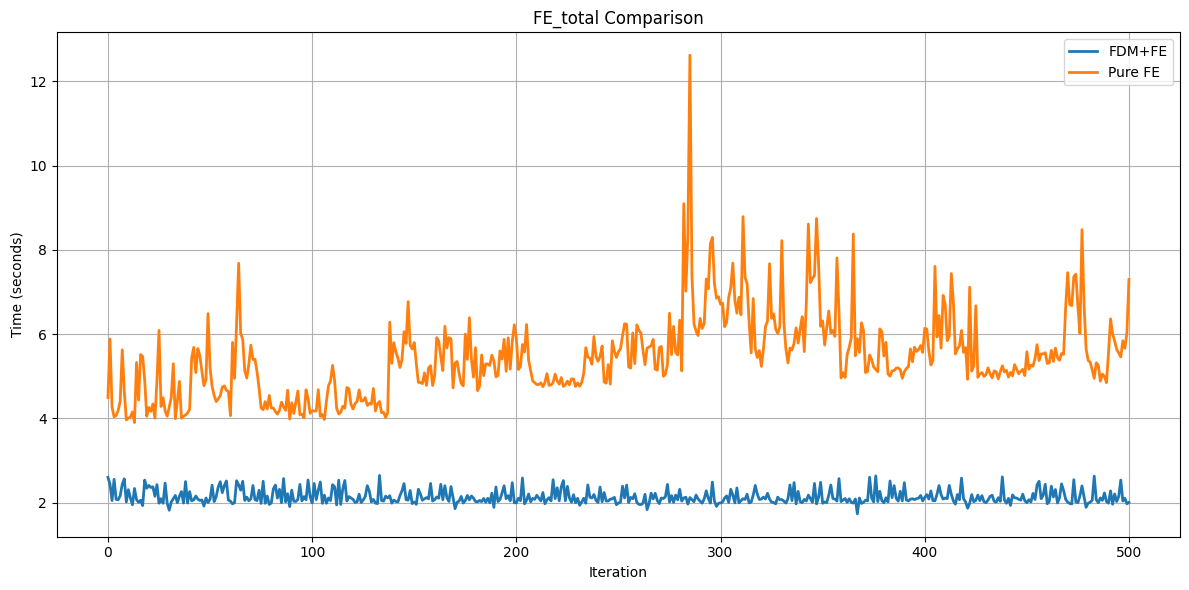

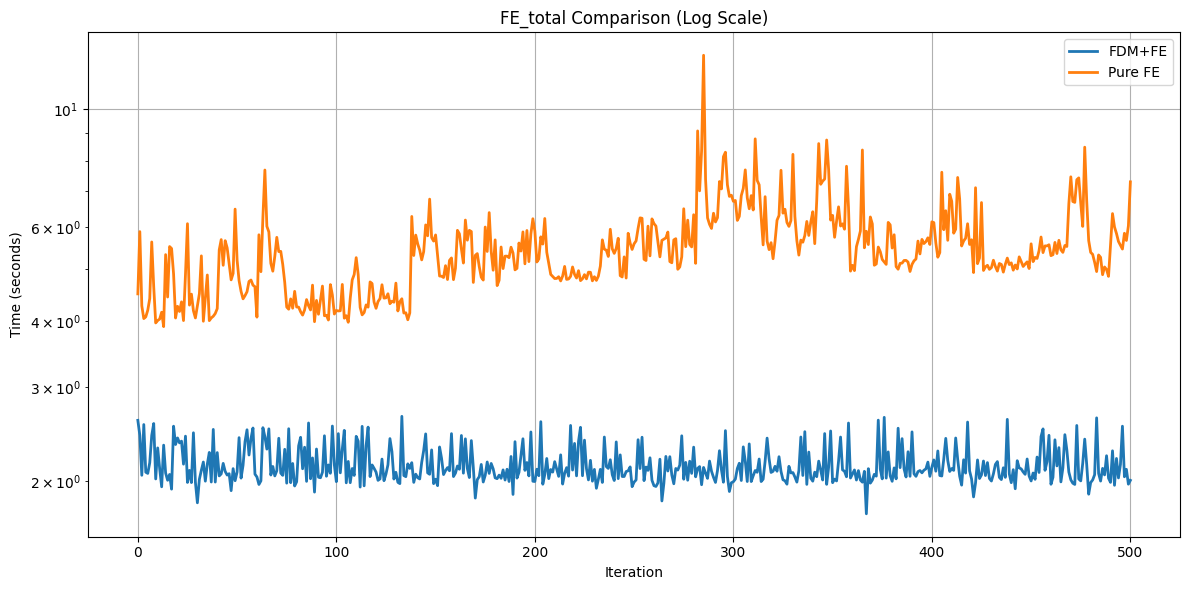

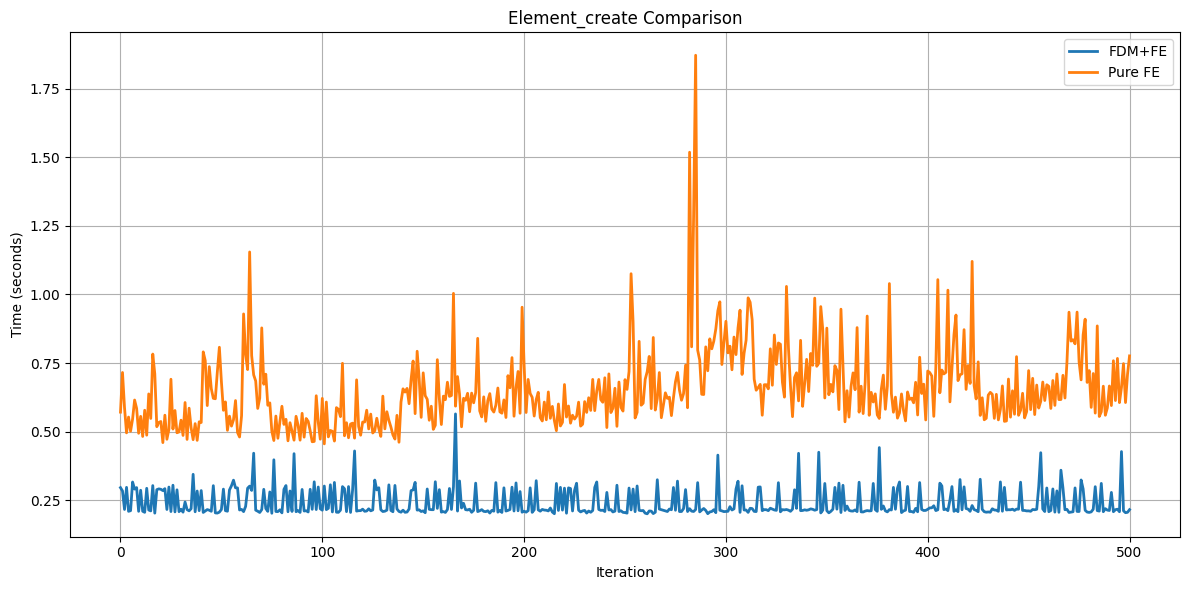

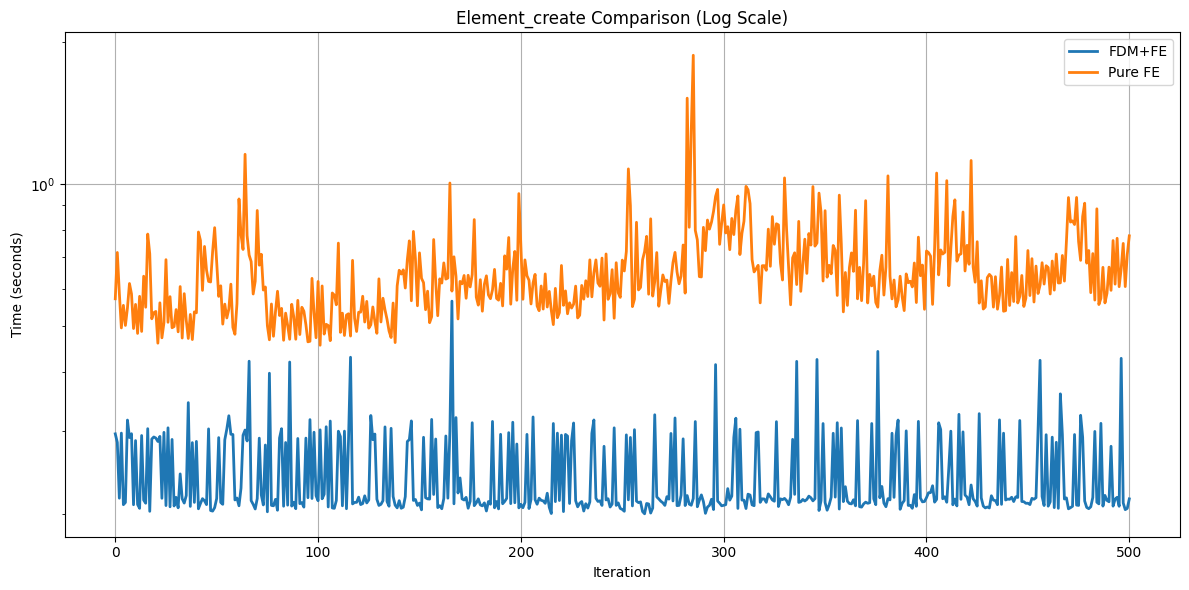

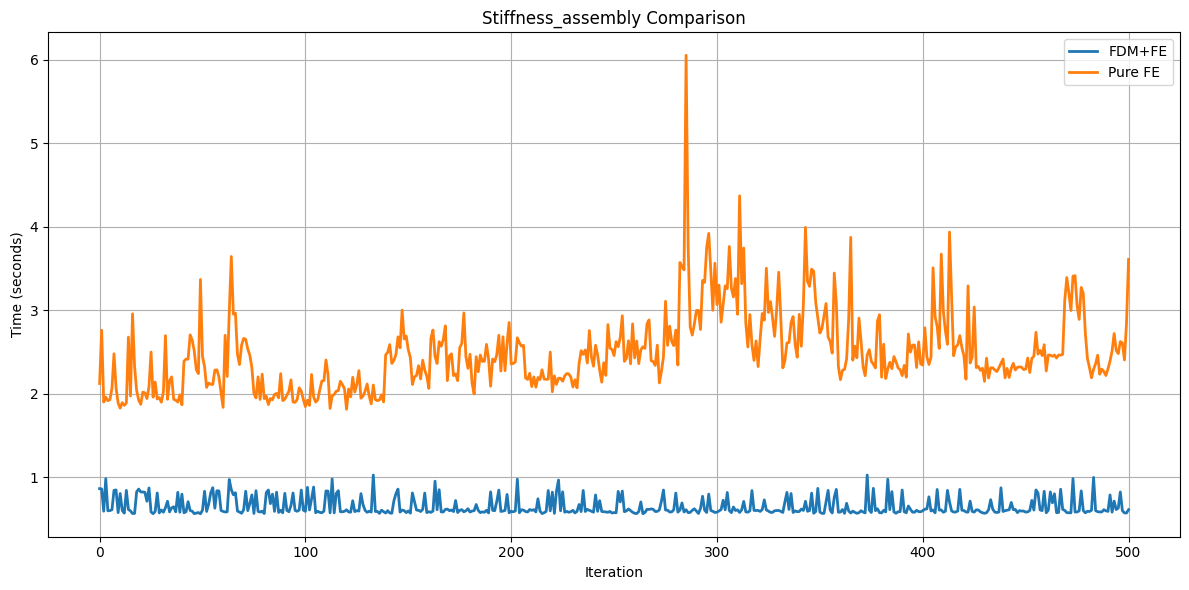

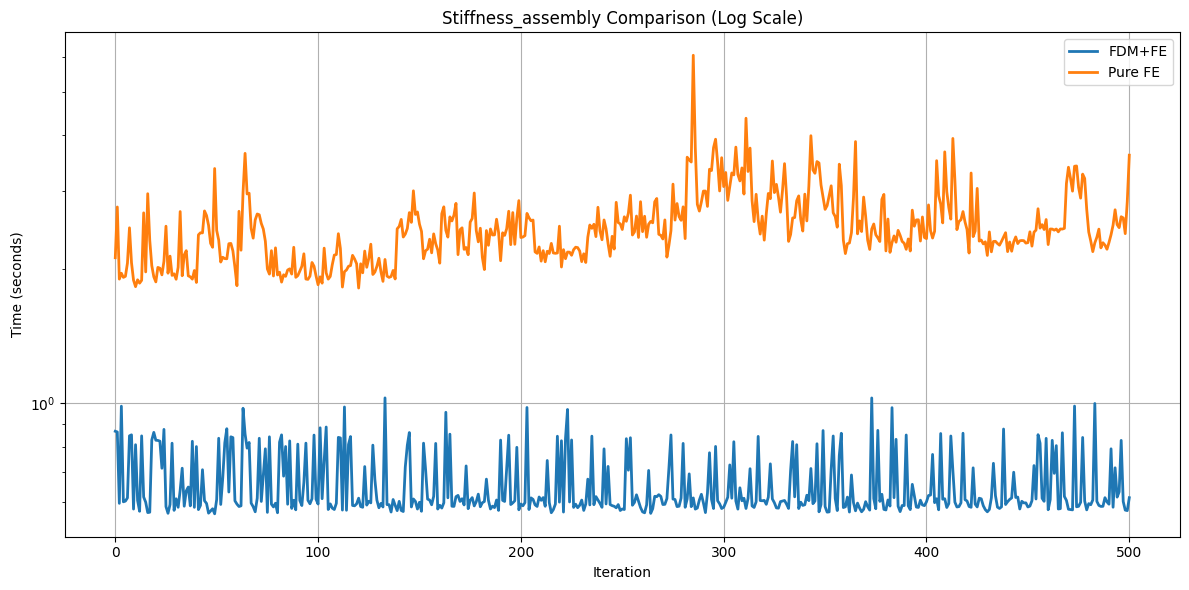

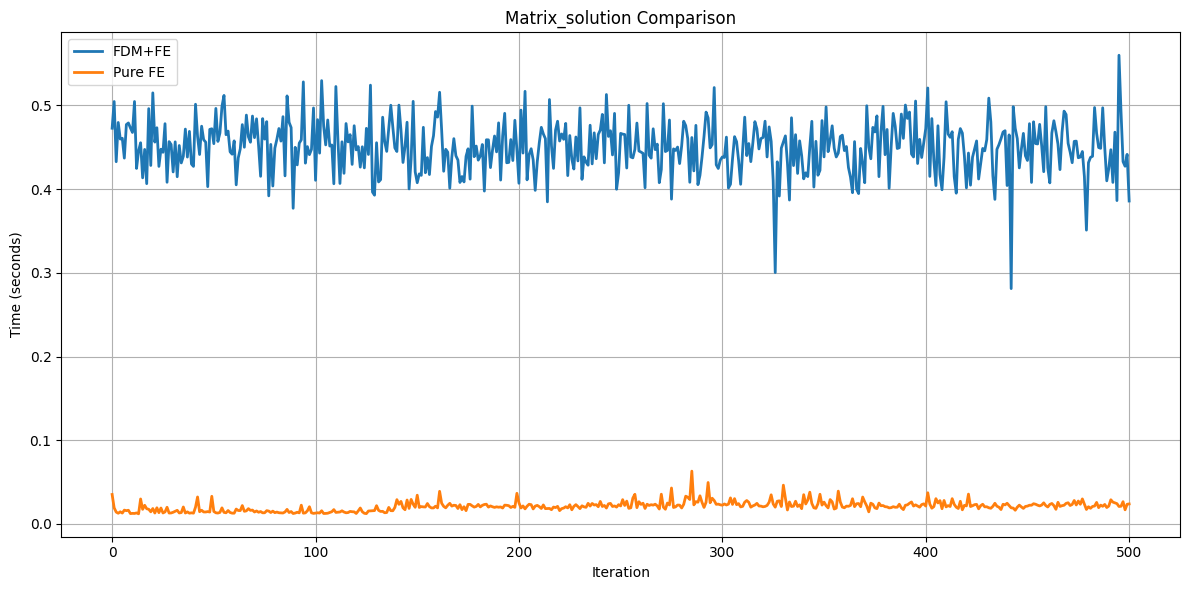

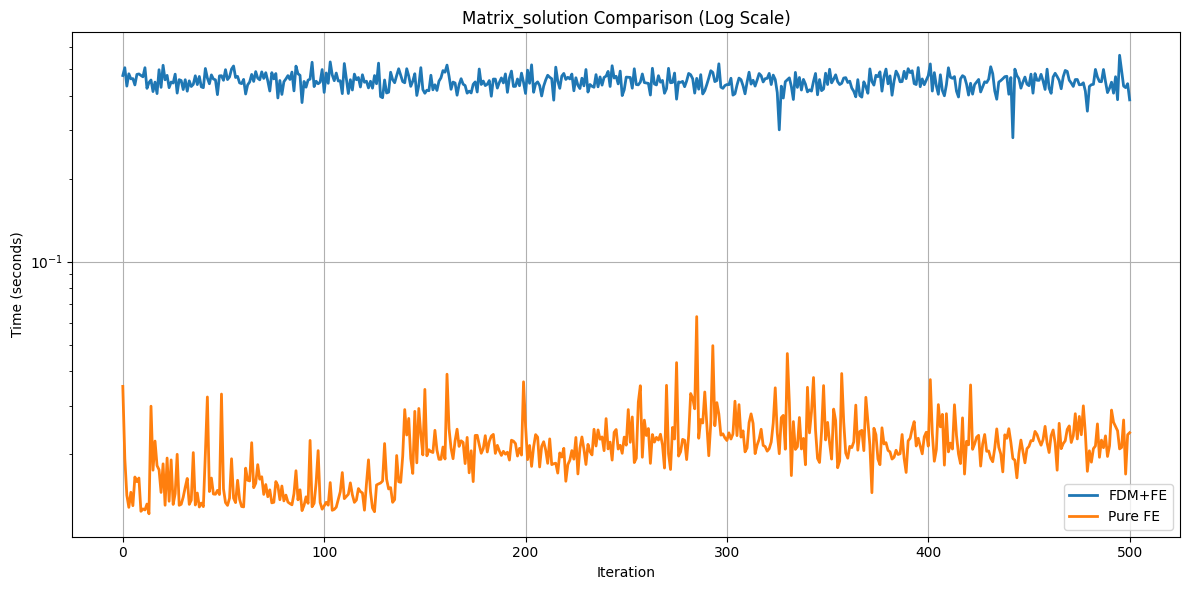

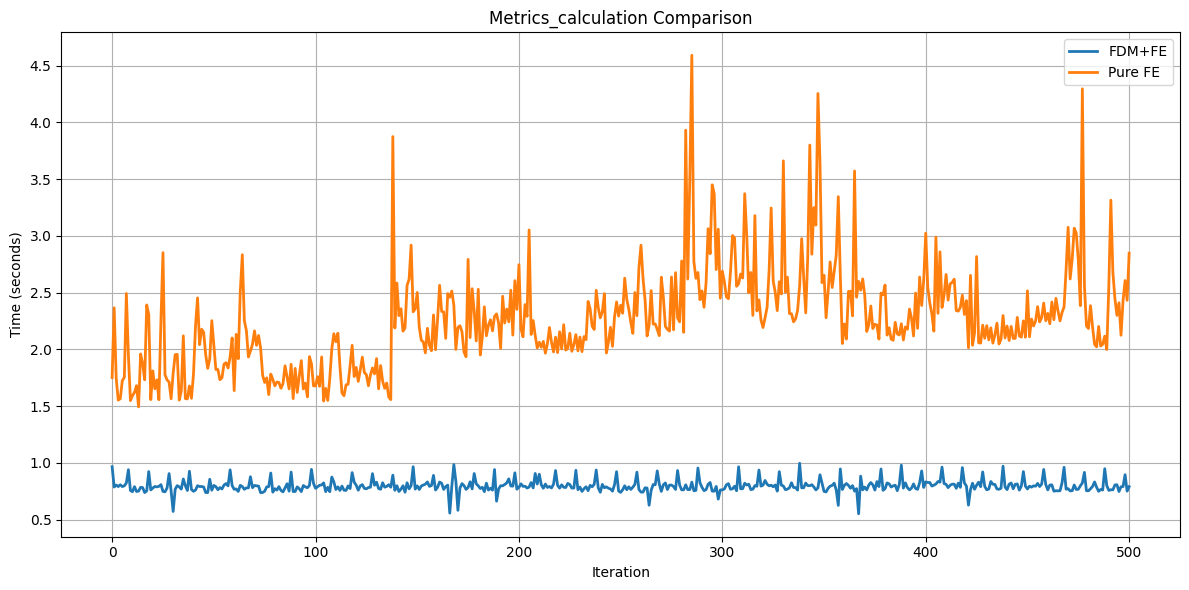

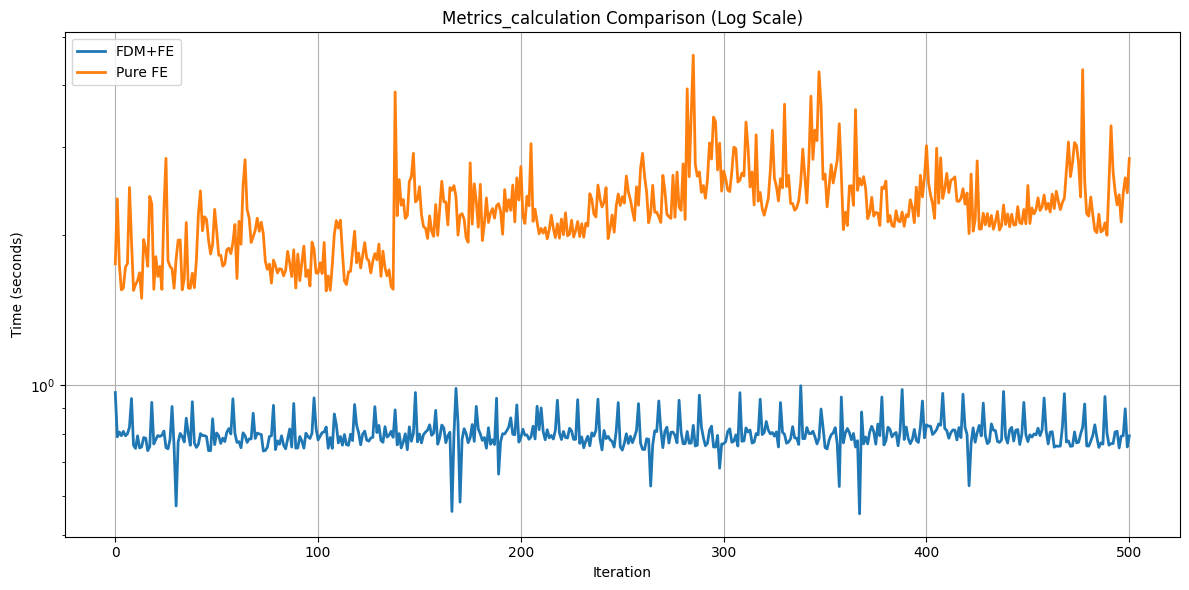

<Figure size 640x480 with 0 Axes>

In [19]:
import json
import matplotlib.pyplot as plt
import numpy as np

# Load both JSON files
with open('FDMg_FEtime.json') as f1, open('FEg_FEtime.json') as f2:
    data_fdm = json.load(f1)  # FDM+FE data
    data_fem = json.load(f2)  # Pure FE data

# Function to extract timing data with consistent naming
def extract_timing_data(data, is_fdm=True):
    timings = []
    for iteration in data['iterations']:
        if is_fdm:
            # For FDM+FE data
            timing = {
                'FE_total': iteration['FE_timing']['Total_FE_time'],
                'Element_create': iteration['FE_timing']['Element_create'],
                'Stiffness_assembly': iteration['FE_timing']['Stiffness_assembly'],
                'Matrix_solution': iteration['FE_timing']['Matrix_solution'],
                'Metrics_calculation': iteration['FE_timing']['Metrics_calculation']
            }
        else:
            # For Pure FE data
            timing = {
                'FE_total': iteration['FE_time'],
                'Element_create': iteration['FE_timing']['Element_create'],
                'Stiffness_assembly': iteration['FE_timing']['Stiffness_assembly'],
                'Matrix_solution': iteration['FE_timing']['Matrix_solution'],
                'Metrics_calculation': iteration['FE_timing']['Metrics_calculation'],
                'Backpropagation': iteration['Backpropagation_time'],
                'Param_update': iteration['Parametric Update']
            }
        timings.append(timing)
    return timings

# Extract timing data
timings_fdm = extract_timing_data(data_fdm, is_fdm=True)
timings_fem = extract_timing_data(data_fem, is_fdm=False)

# Common components for comparison
common_components = [
    'FE_total',
    'Element_create',
    'Stiffness_assembly',
    'Matrix_solution',
    'Metrics_calculation'
]

# Plotting function for comparison
def plot_comparison(component, ylabel='Time (seconds)', log_scale=False):
    plt.figure(figsize=(12, 6))
    
    # FDM+FE data
    fdm_values = [t[component] for t in timings_fdm]
    plt.plot(range(len(fdm_values)), fdm_values, 
             linestyle='-', linewidth=2, label='FDM+FE')
    
    # Pure FE data
    fem_values = [t[component] for t in timings_fem]
    plt.plot(range(len(fem_values)), fem_values,
             linestyle='-', linewidth=2, label='Pure FE')
    
    plt.xlabel('Iteration')
    plt.ylabel(ylabel)
    plt.title(f'{component} Comparison')
    plt.legend()
    plt.grid(True)
    
    if log_scale:
        plt.yscale('log')
        plt.title(f'{component} Comparison (Log Scale)')
    
    plt.tight_layout()
    plt.show()

# Plot individual component comparisons
for comp in common_components:
    plot_comparison(comp)
    plot_comparison(comp, log_scale=True)  # Log scale version

# # Calculate and display statistics
# def calculate_stats(timings, components):
#     stats = {}
#     for comp in components:
#         values = [t[comp] for t in timings]
#         stats[comp] = {
#             'mean': np.mean(values),
#             'max': np.max(values),
#             'min': np.min(values),
#             'std': np.std(values)
#         }
#     return stats

# # Plot side-by-side comparison of means - MODIFIED VERSION
# # Define custom order with FE_total first
# components_ordered = ['FE_total'] + [comp for comp in sorted(common_components) if comp != 'FE_total']

# fdm_means = [fdm_stats[comp]['mean'] for comp in components_ordered]
# fem_means = [fem_stats[comp]['mean'] for comp in components_ordered]

# x = np.arange(len(components_ordered))
# width = 0.35

# fig, ax = plt.subplots(figsize=(12, 6))
# rects1 = ax.bar(x - width/2, fdm_means, width, label='FDM+FE')
# rects2 = ax.bar(x + width/2, fem_means, width, label='Pure FE')

# # Add value labels on top of each bar
# def autolabel(rects):
#     for rect in rects:
#         height = rect.get_height()
#         ax.annotate(f'{height:.2f}',
#                     xy=(rect.get_x() + rect.get_width() / 2, height),
#                     xytext=(0, 3),  # 3 points vertical offset
#                     textcoords="offset points",
#                     ha='center', va='bottom')

# autolabel(rects1)
# autolabel(rects2)

ax.set_ylabel('Time (seconds)')
ax.set_title('Mean Time Comparison by Component')
ax.set_xticks(x)
ax.set_xticklabels(components_ordered, rotation=45)
ax.legend()
ax.grid(True, axis='y')

fig.tight_layout()
plt.savefig("mean_time_comparison.png", bbox_inches='tight', dpi=300)
plt.show()

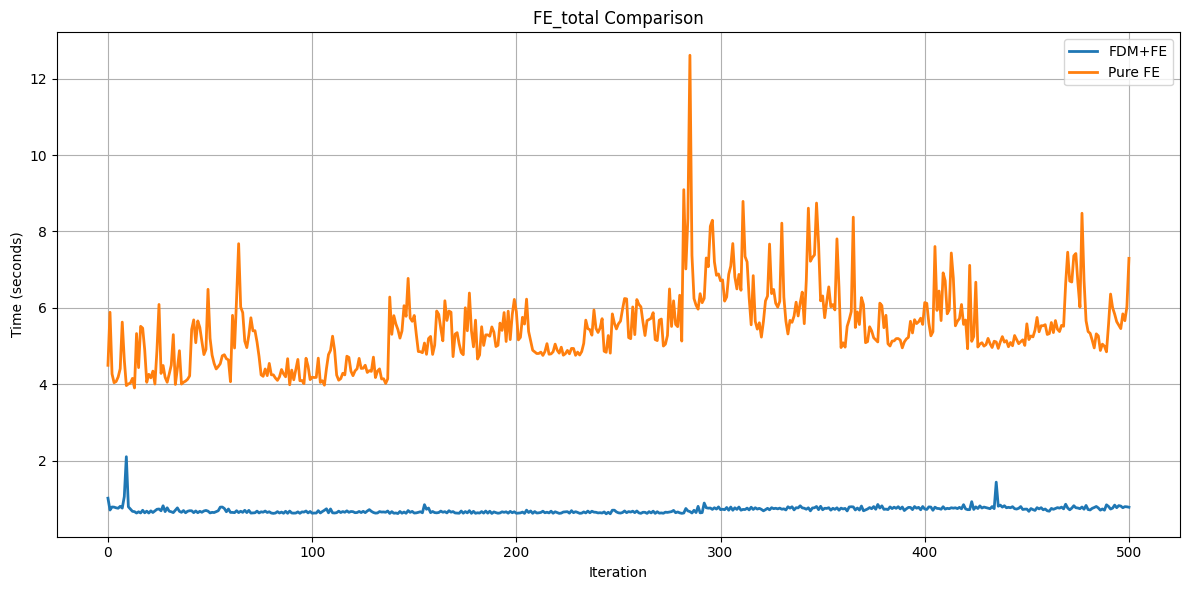

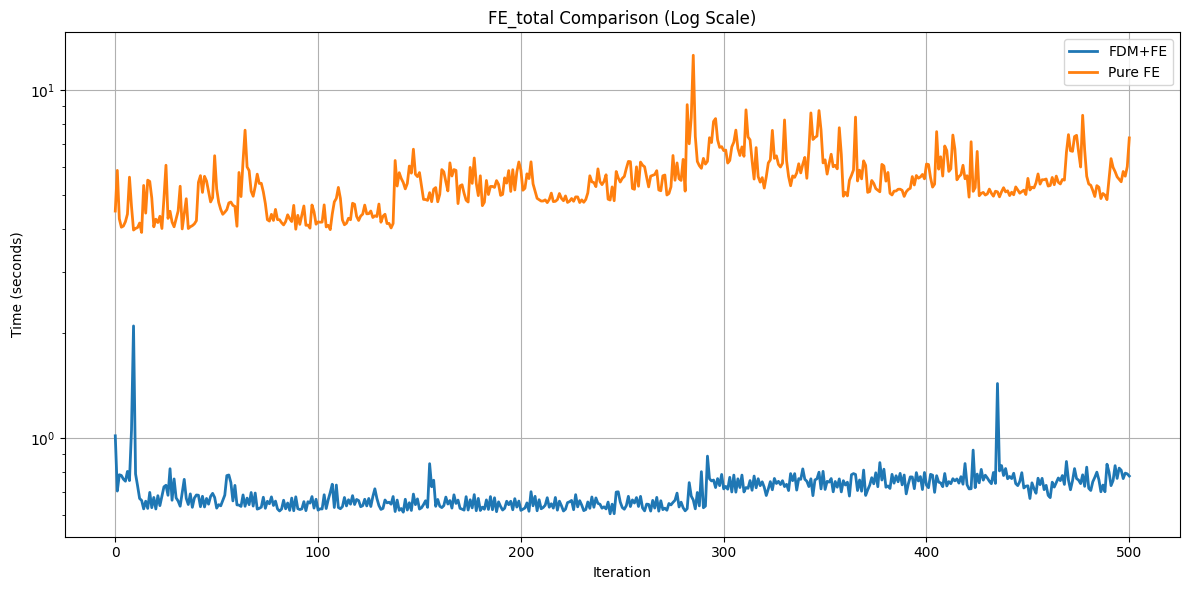

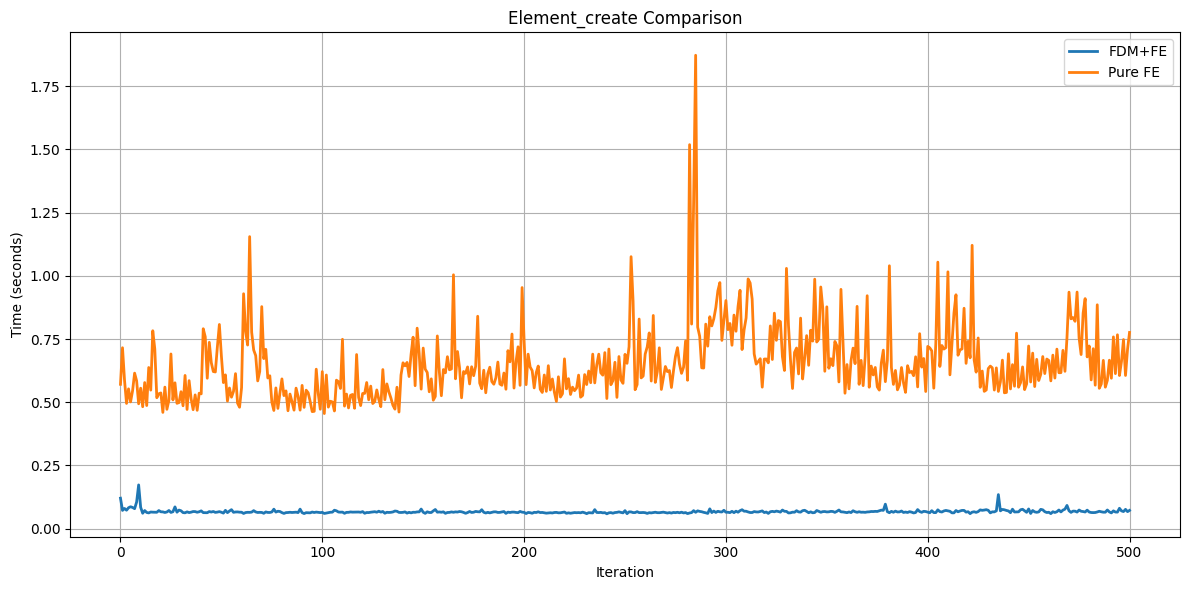

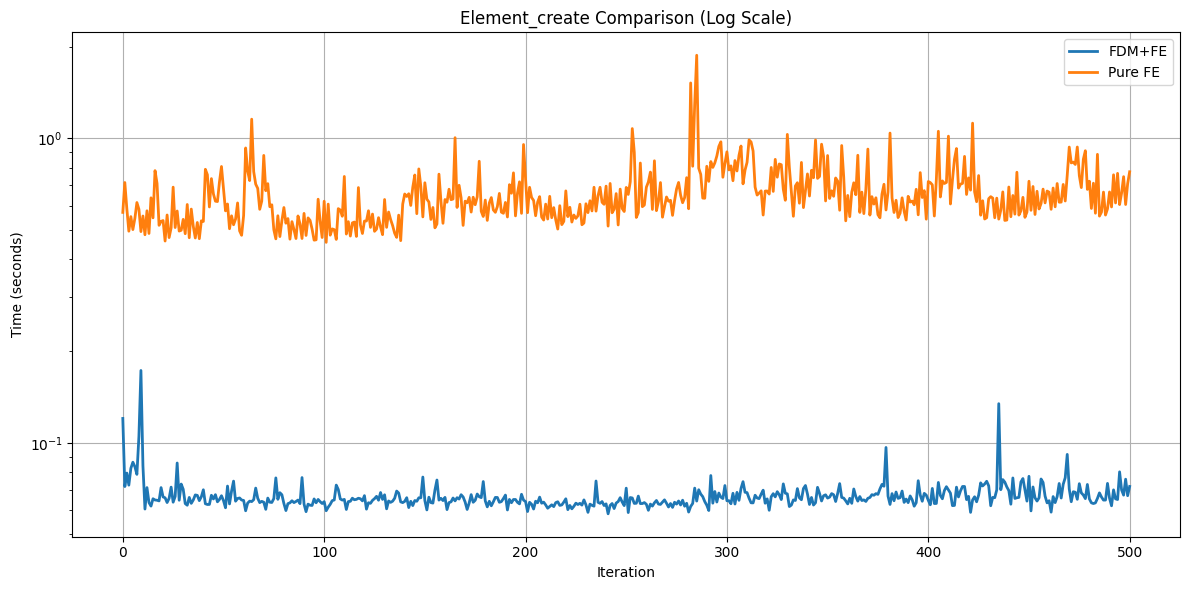

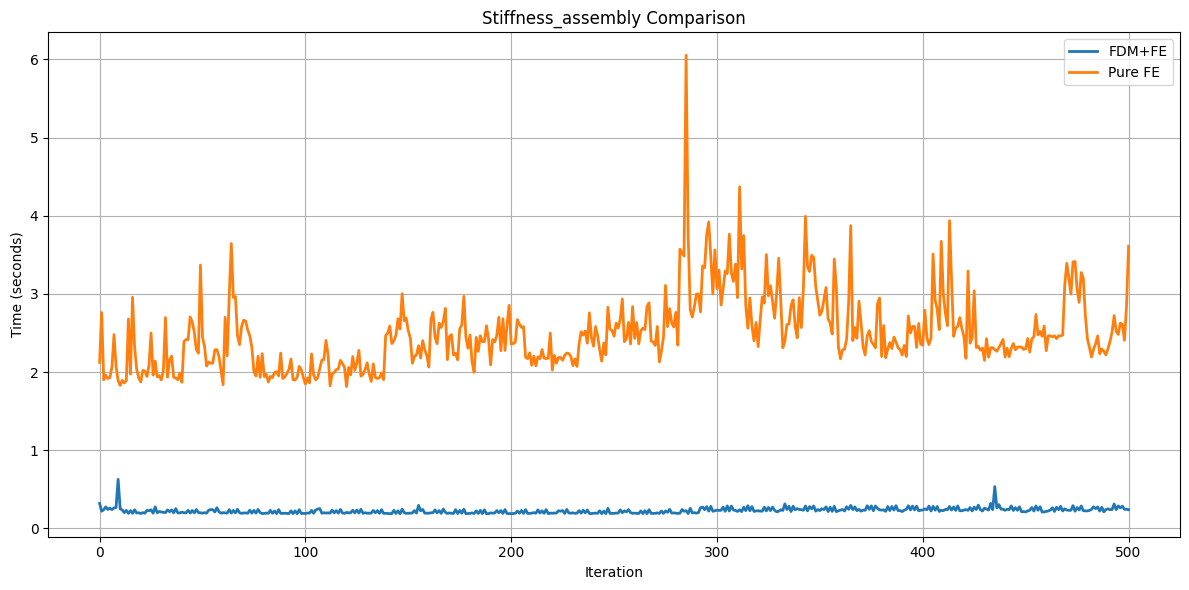

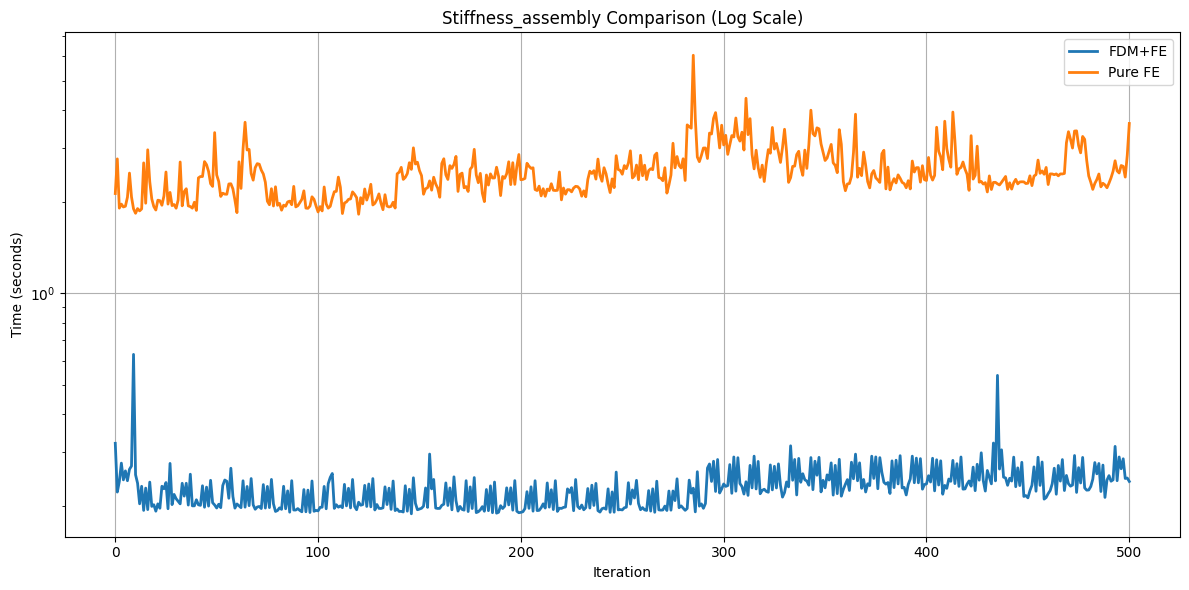

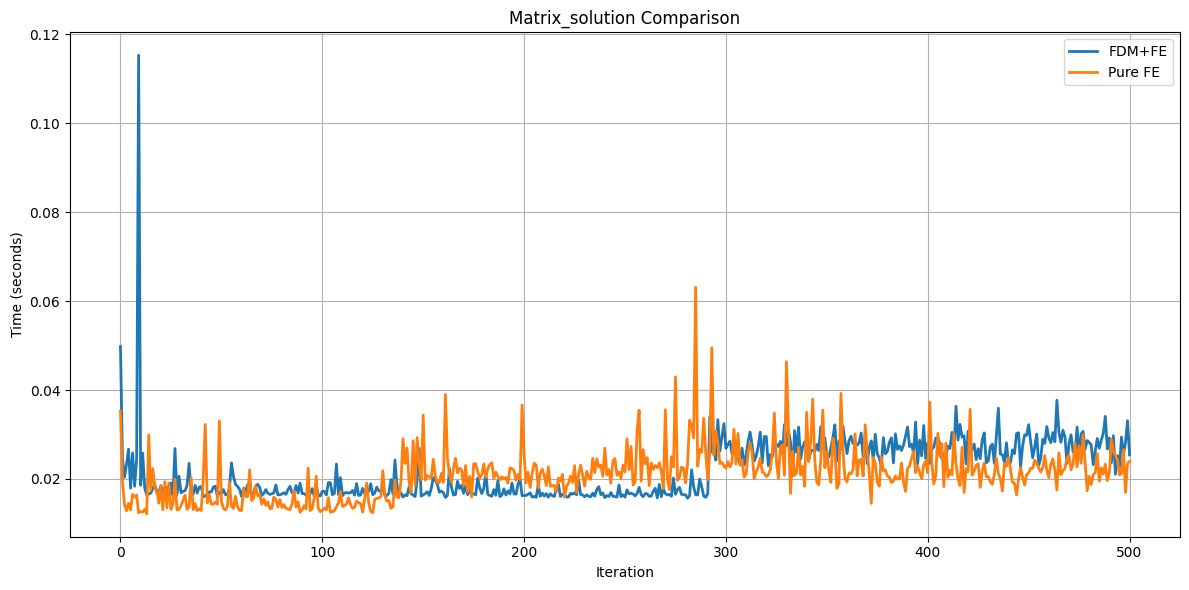

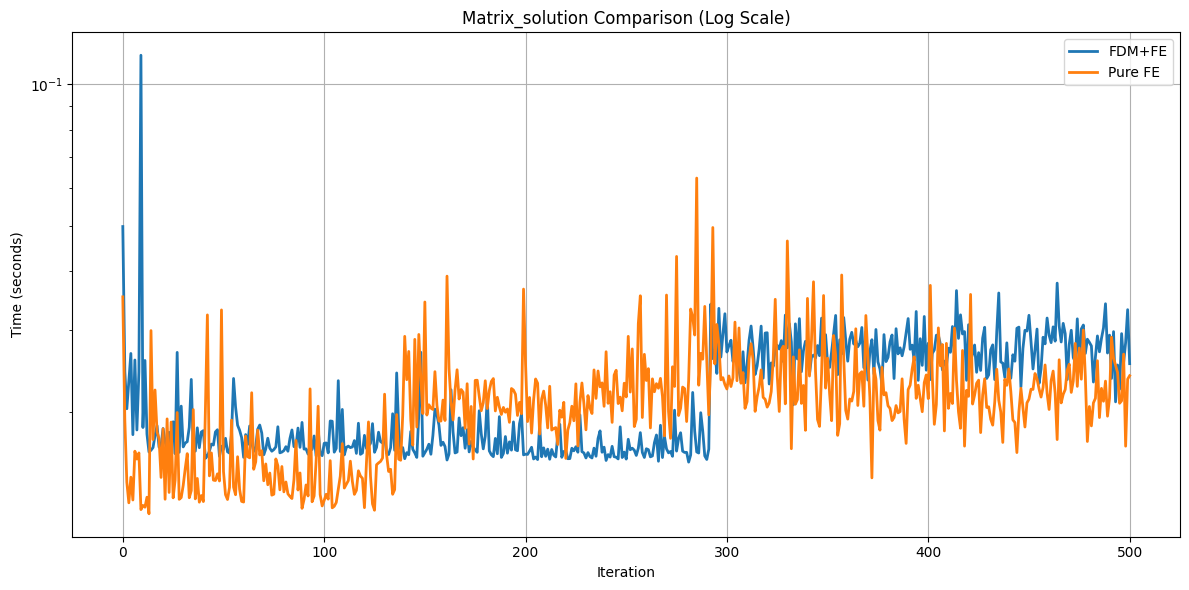

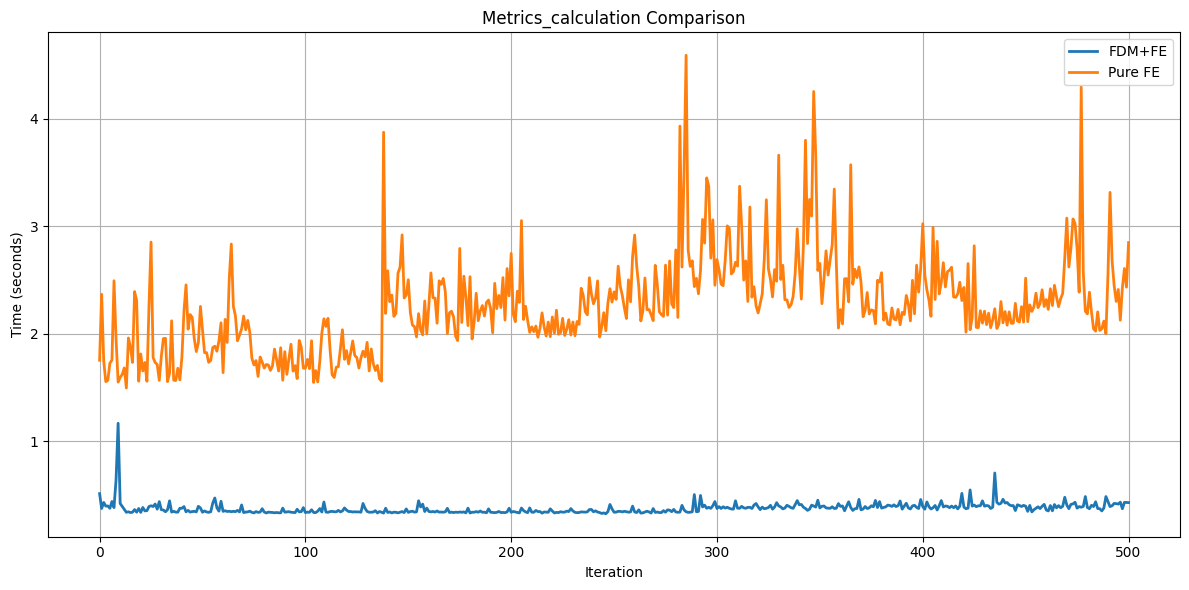

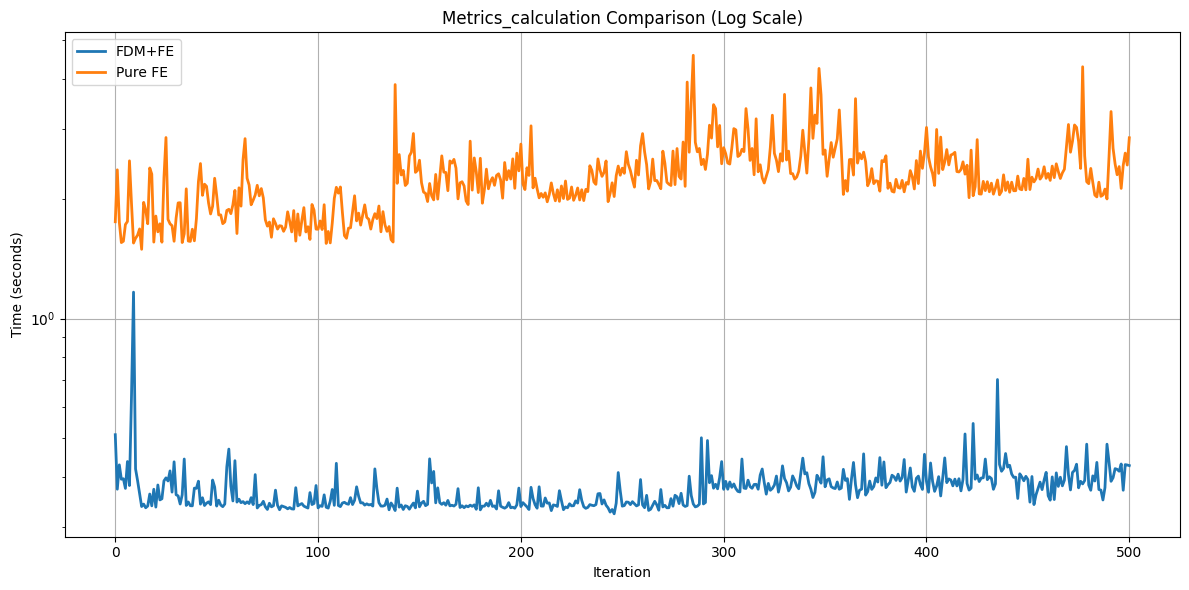

<Figure size 640x480 with 0 Axes>

In [22]:
import json
import matplotlib.pyplot as plt
import numpy as np

# Load both JSON files
with open('FDM2_FEtime.json') as f1, open('FEg_FEtime.json') as f2:
    data_fdm = json.load(f1)  # FDM+FE data
    data_fem = json.load(f2)  # Pure FE data

# Function to extract timing data with consistent naming
def extract_timing_data(data, is_fdm=True):
    timings = []
    for iteration in data['iterations']:
        if is_fdm:
            # For FDM+FE data
            timing = {
                'FE_total': iteration['FE_time'],
                'Element_create': iteration['FE_timing']['Element_create'],
                'Stiffness_assembly': iteration['FE_timing']['Stiffness_assembly'],
                'Matrix_solution': iteration['FE_timing']['Matrix_solution'],
                'Metrics_calculation': iteration['FE_timing']['Metrics_calculation'],
                'Backpropagation': iteration['Backpropagation_time'],
                'Param_update': iteration['Parametric Update']
            }
        else:
            # For Pure FE data
            timing = {
                'FE_total': iteration['FE_time'],
                'Element_create': iteration['FE_timing']['Element_create'],
                'Stiffness_assembly': iteration['FE_timing']['Stiffness_assembly'],
                'Matrix_solution': iteration['FE_timing']['Matrix_solution'],
                'Metrics_calculation': iteration['FE_timing']['Metrics_calculation'],
                'Backpropagation': iteration['Backpropagation_time'],
                'Param_update': iteration['Parametric Update']
            }
        timings.append(timing)
    return timings

# Extract timing data
timings_fdm = extract_timing_data(data_fdm, is_fdm=True)
timings_fem = extract_timing_data(data_fem, is_fdm=False)

# Common components for comparison
common_components = [
    'FE_total',
    'Element_create',
    'Stiffness_assembly',
    'Matrix_solution',
    'Metrics_calculation'
]

# Plotting function for comparison
def plot_comparison(component, ylabel='Time (seconds)', log_scale=False):
    plt.figure(figsize=(12, 6))
    
    # FDM+FE data
    fdm_values = [t[component] for t in timings_fdm]
    plt.plot(range(len(fdm_values)), fdm_values, 
             linestyle='-', linewidth=2, label='FDM+FE')
    
    # Pure FE data
    fem_values = [t[component] for t in timings_fem]
    plt.plot(range(len(fem_values)), fem_values,
             linestyle='-', linewidth=2, label='Pure FE')
    
    plt.xlabel('Iteration')
    plt.ylabel(ylabel)
    plt.title(f'{component} Comparison')
    plt.legend()
    plt.grid(True)
    
    if log_scale:
        plt.yscale('log')
        plt.title(f'{component} Comparison (Log Scale)')
    
    plt.tight_layout()
    plt.show()

# Plot individual component comparisons
for comp in common_components:
    plot_comparison(comp)
    plot_comparison(comp, log_scale=True)  # Log scale version

# # Calculate and display statistics
# def calculate_stats(timings, components):
#     stats = {}
#     for comp in components:
#         values = [t[comp] for t in timings]
#         stats[comp] = {
#             'mean': np.mean(values),
#             'max': np.max(values),
#             'min': np.min(values),
#             'std': np.std(values)
#         }
#     return stats

# # Plot side-by-side comparison of means - MODIFIED VERSION
# # Define custom order with FE_total first
# components_ordered = ['FE_total'] + [comp for comp in sorted(common_components) if comp != 'FE_total']

# fdm_means = [fdm_stats[comp]['mean'] for comp in components_ordered]
# fem_means = [fem_stats[comp]['mean'] for comp in components_ordered]

# x = np.arange(len(components_ordered))
# width = 0.35

# fig, ax = plt.subplots(figsize=(12, 6))
# rects1 = ax.bar(x - width/2, fdm_means, width, label='FDM+FE')
# rects2 = ax.bar(x + width/2, fem_means, width, label='Pure FE')

# # Add value labels on top of each bar
# def autolabel(rects):
#     for rect in rects:
#         height = rect.get_height()
#         ax.annotate(f'{height:.2f}',
#                     xy=(rect.get_x() + rect.get_width() / 2, height),
#                     xytext=(0, 3),  # 3 points vertical offset
#                     textcoords="offset points",
#                     ha='center', va='bottom')

# autolabel(rects1)
# autolabel(rects2)

ax.set_ylabel('Time (seconds)')
ax.set_title('Mean Time Comparison by Component')
ax.set_xticks(x)
ax.set_xticklabels(components_ordered, rotation=45)
ax.legend()
ax.grid(True, axis='y')

fig.tight_layout()
plt.savefig("t3.png", bbox_inches='tight', dpi=300)
plt.show()

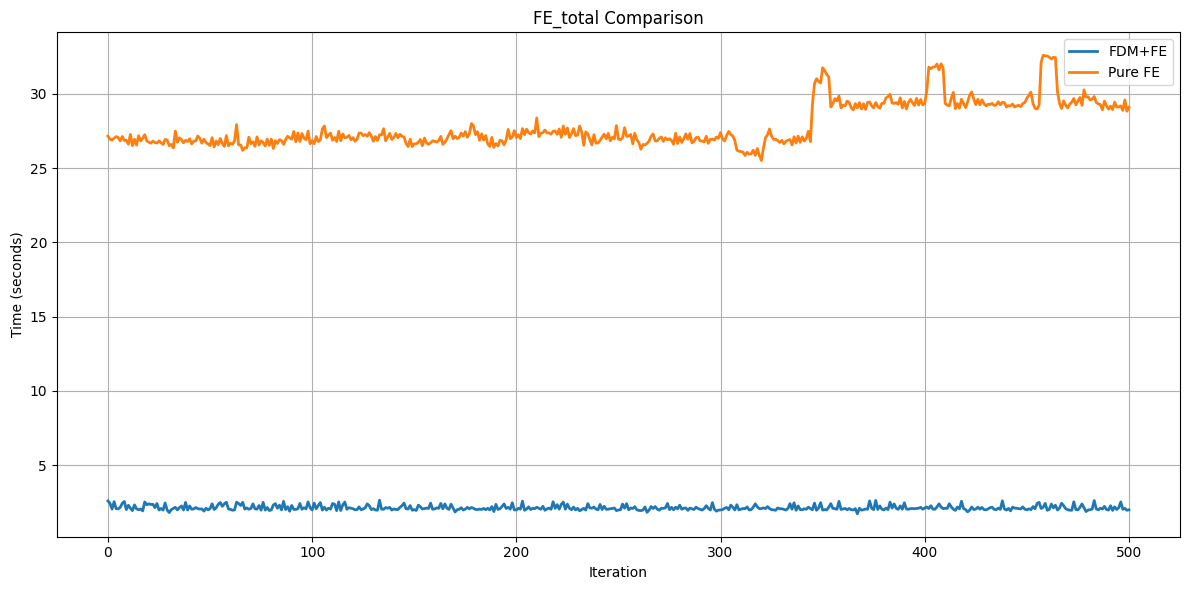

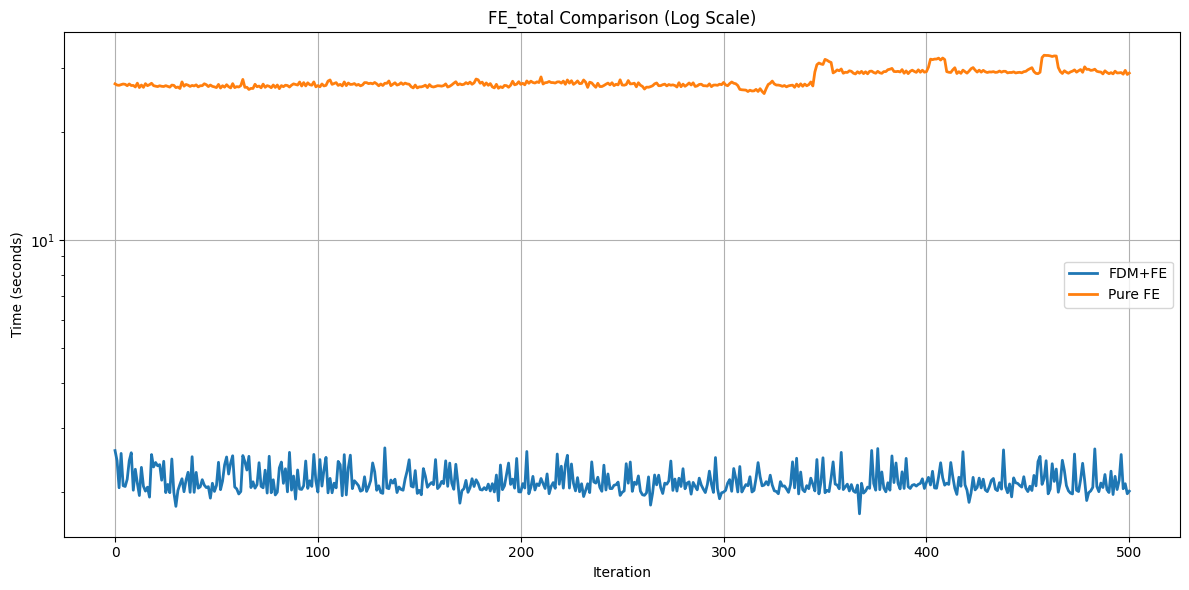

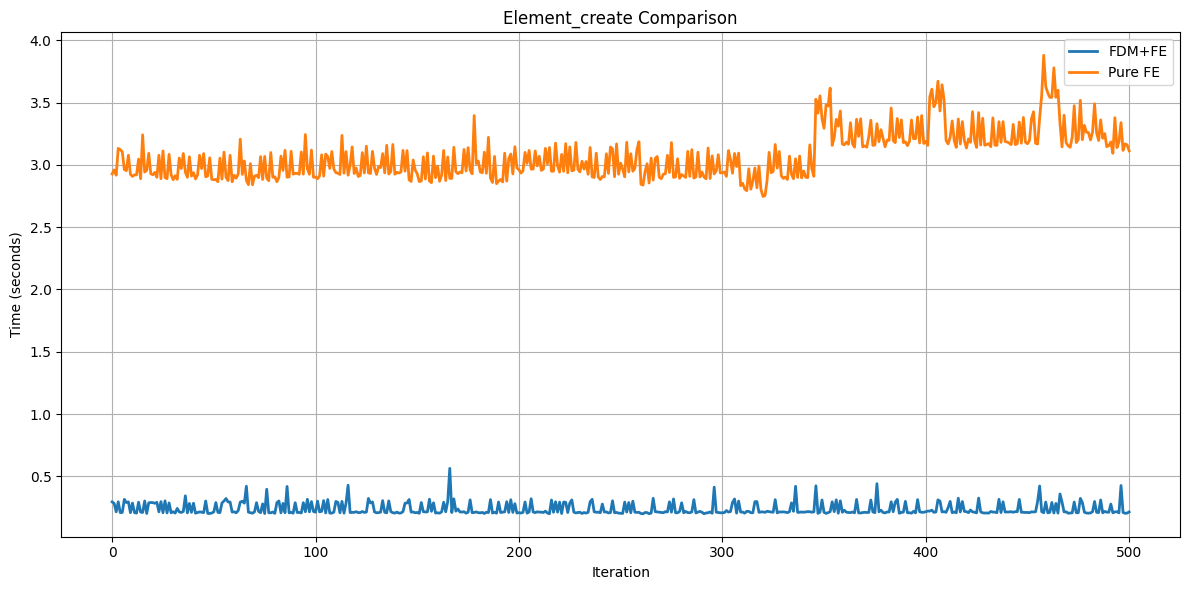

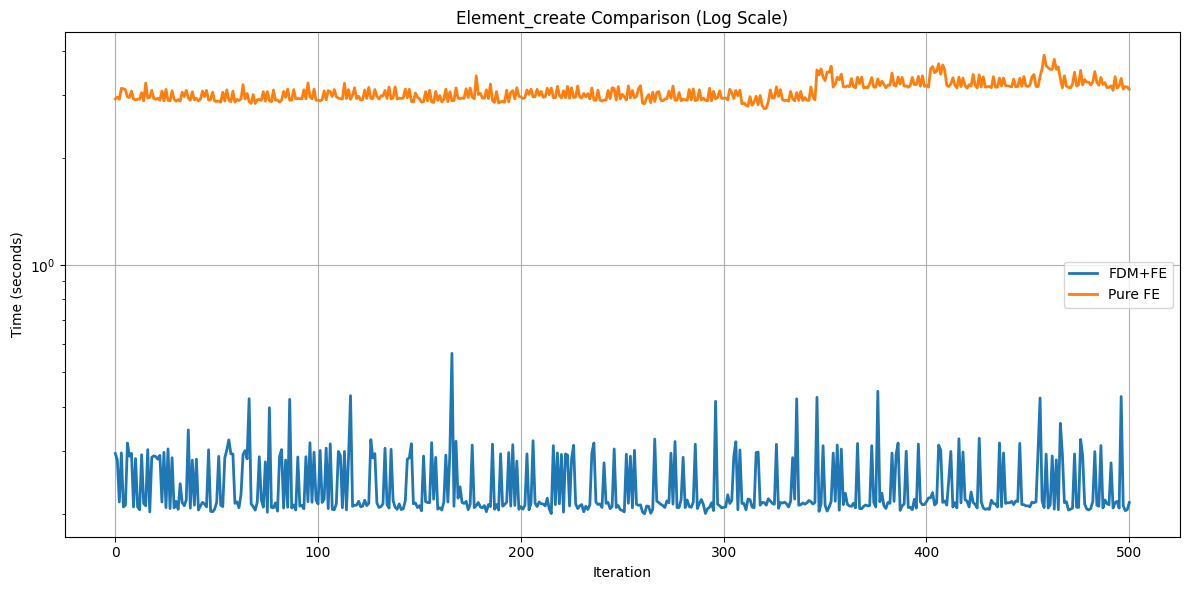

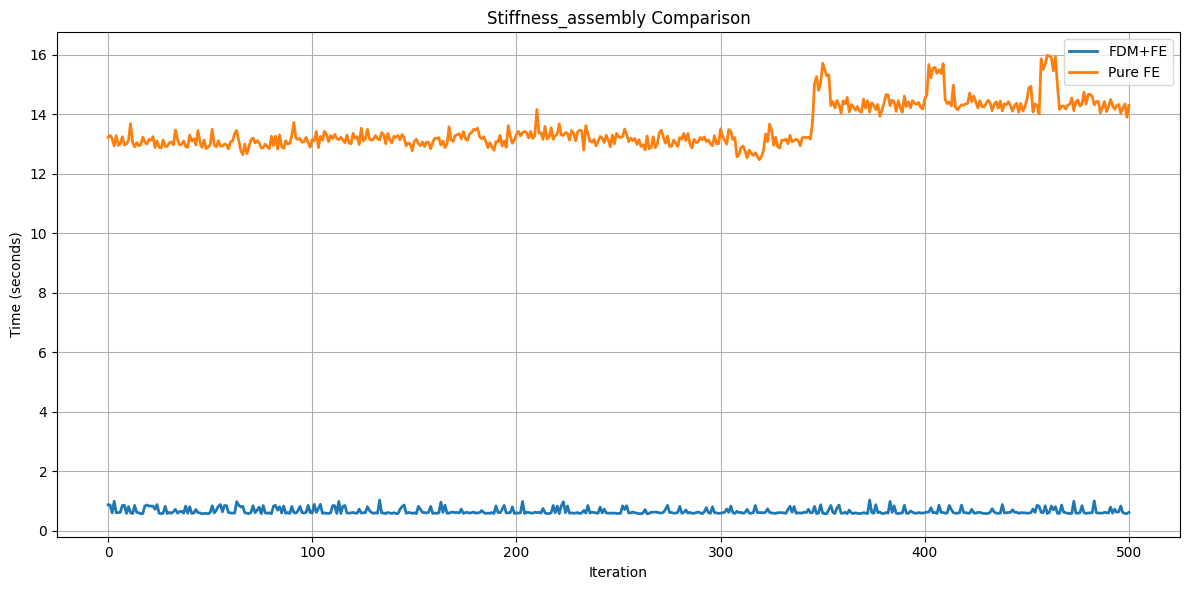

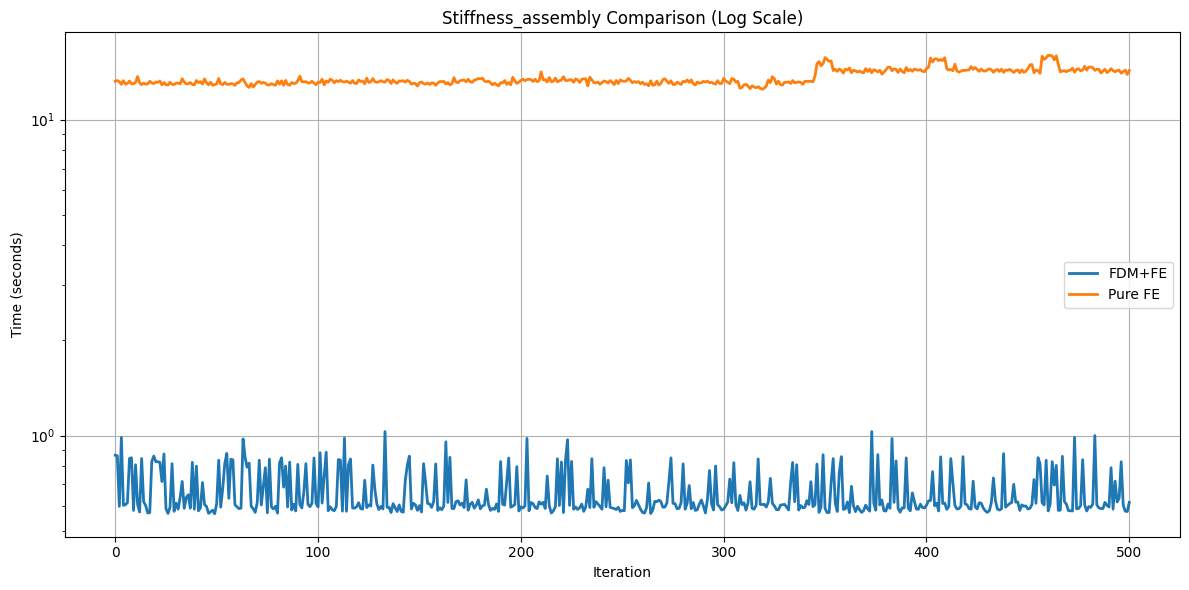

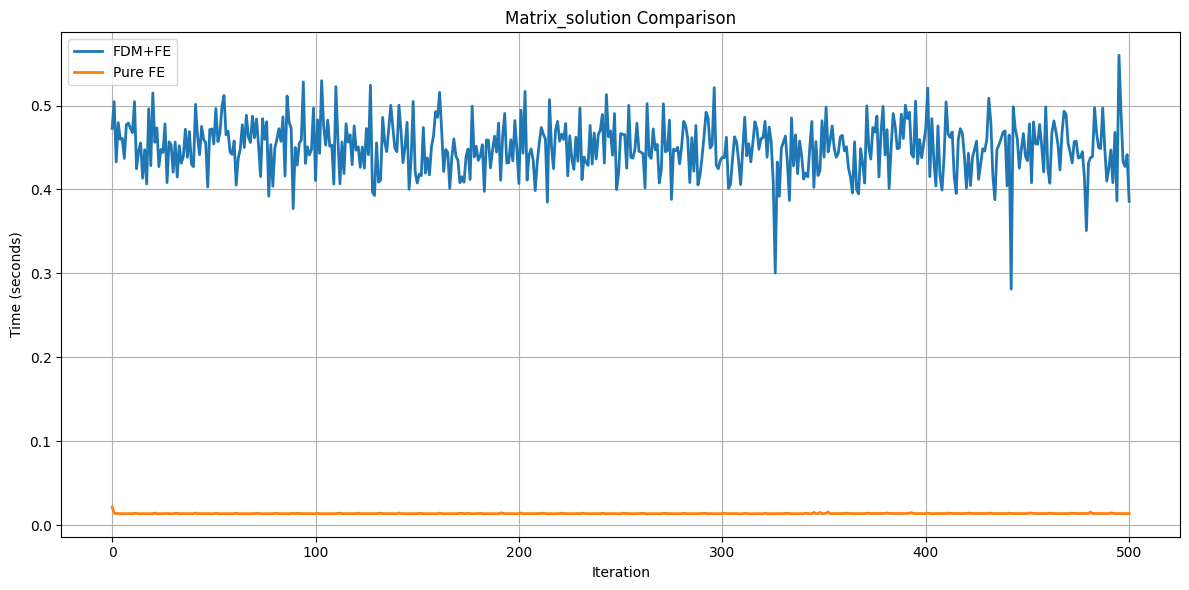

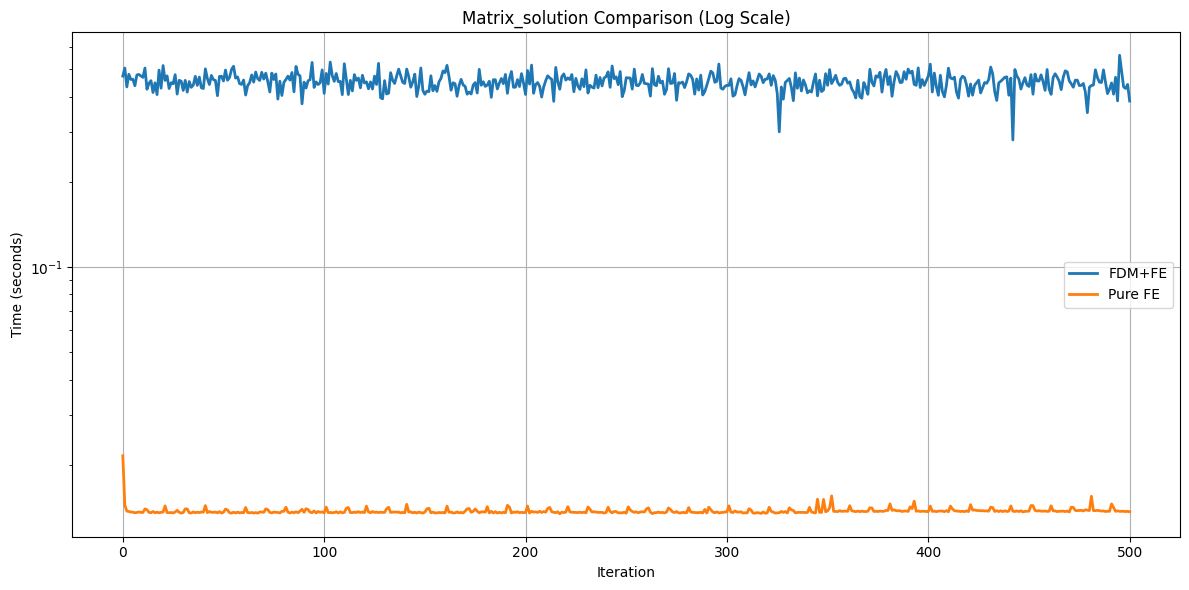

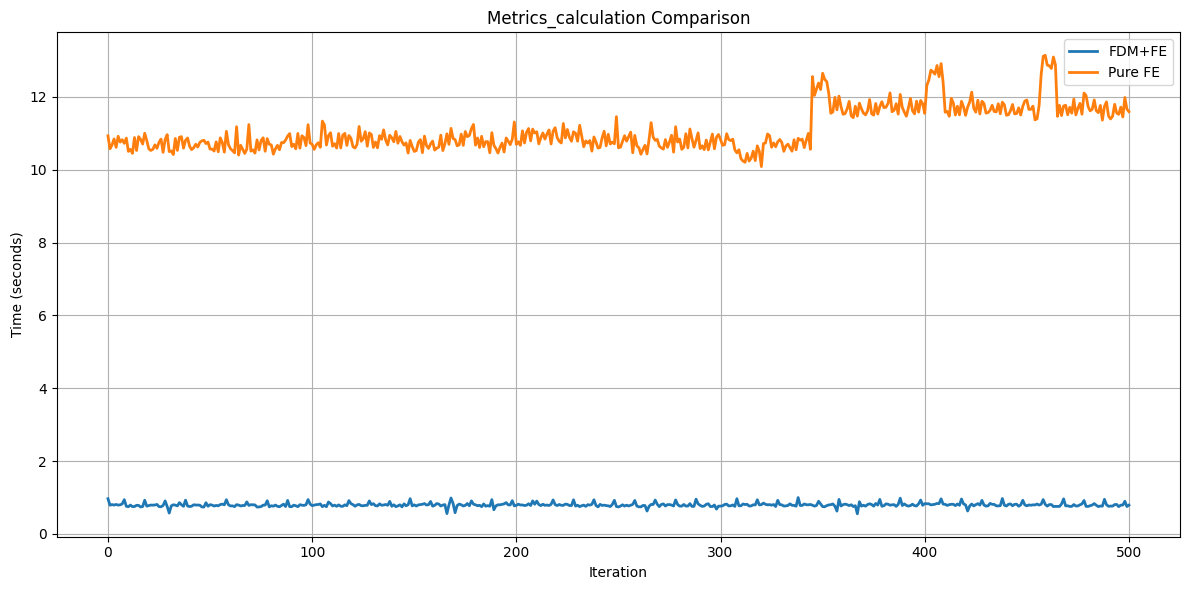

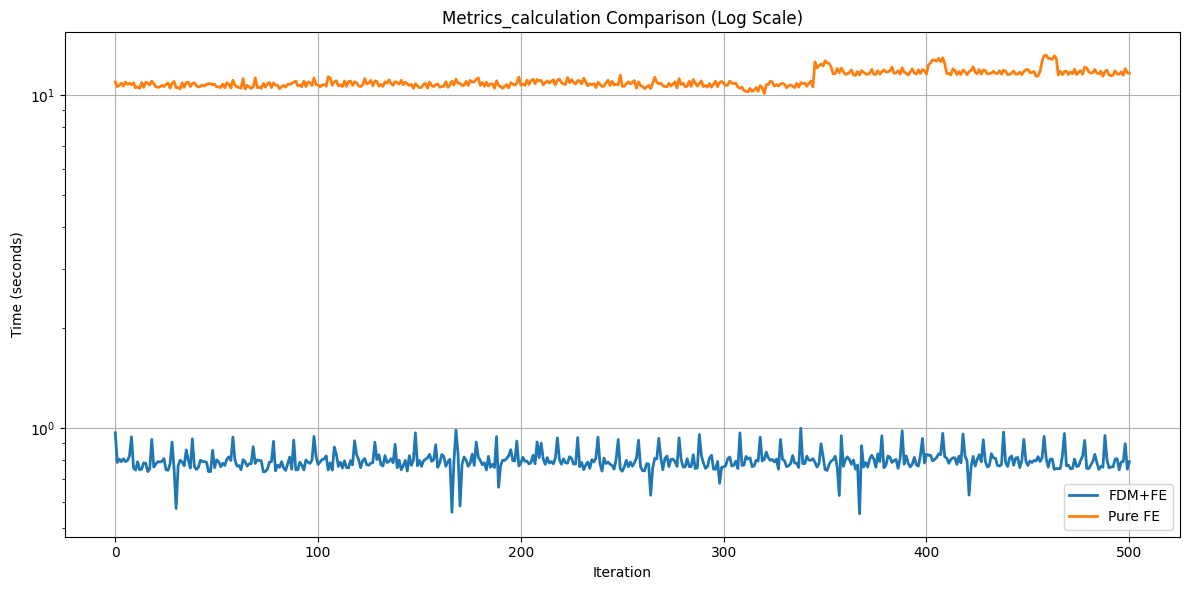

NameError: name 'fdm_stats' is not defined

In [18]:
import json
import matplotlib.pyplot as plt
import numpy as np

# Load both JSON files
with open('FDMg_FEtime.json') as f1, open('FEg_time_FE.json') as f2:
    data_fdm = json.load(f1)  # FDM+FE data
    data_fem = json.load(f2)  # Pure FE data

# Function to extract timing data with consistent naming
def extract_timing_data(data, is_fdm=True):
    timings = []
    for iteration in data['iterations']:
        if is_fdm:
            # For FDM+FE data
            timing = {
                'FE_total': iteration['FE_timing']['Total_FE_time'],
                'Element_create': iteration['FE_timing']['Element_create'],
                'Stiffness_assembly': iteration['FE_timing']['Stiffness_assembly'],
                'Matrix_solution': iteration['FE_timing']['Matrix_solution'],
                'Metrics_calculation': iteration['FE_timing']['Metrics_calculation']
            }
        else:
            # For Pure FE data
            timing = {
                'FE_total': iteration['FE_time'],
                'Element_create': iteration['FE_timing']['Element_create'],
                'Stiffness_assembly': iteration['FE_timing']['Stiffness_assembly'],
                'Matrix_solution': iteration['FE_timing']['Matrix_solution'],
                'Metrics_calculation': iteration['FE_timing']['Metrics_calculation'],
                'Backpropagation': iteration['Backpropagation_time'],
                'Param_update': iteration['Parametric Update']
            }
        timings.append(timing)
    return timings

# Extract timing data
timings_fdm = extract_timing_data(data_fdm, is_fdm=True)
timings_fem = extract_timing_data(data_fem, is_fdm=False)

# Common components for comparison
common_components = [
    'FE_total',
    'Element_create',
    'Stiffness_assembly',
    'Matrix_solution',
    'Metrics_calculation'
]

# Plotting function for comparison
def plot_comparison(component, ylabel='Time (seconds)', log_scale=False):
    plt.figure(figsize=(12, 6))
    
    # FDM+FE data
    fdm_values = [t[component] for t in timings_fdm]
    plt.plot(range(len(fdm_values)), fdm_values, 
             linestyle='-', linewidth=2, label='FDM+FE')
    
    # Pure FE data
    fem_values = [t[component] for t in timings_fem]
    plt.plot(range(len(fem_values)), fem_values,
             linestyle='-', linewidth=2, label='Pure FE')
    
    plt.xlabel('Iteration')
    plt.ylabel(ylabel)
    plt.title(f'{component} Comparison')
    plt.legend()
    plt.grid(True)
    
    if log_scale:
        plt.yscale('log')
        plt.title(f'{component} Comparison (Log Scale)')
    
    plt.tight_layout()
    plt.show()

# Plot individual component comparisons
for comp in common_components:
    plot_comparison(comp)
    plot_comparison(comp, log_scale=True)  # Log scale version

# Calculate and display statistics
def calculate_stats(timings, components):
    stats = {}
    for comp in components:
        values = [t[comp] for t in timings]
        stats[comp] = {
            'mean': np.mean(values),
            'max': np.max(values),
            'min': np.min(values),
            'std': np.std(values)
        }
    return stats

# Plot side-by-side comparison of means - MODIFIED VERSION
# Define custom order with FE_total first
components_ordered = ['FE_total'] + [comp for comp in sorted(common_components) if comp != 'FE_total']

fdm_means = [fdm_stats[comp]['mean'] for comp in components_ordered]
fem_means = [fem_stats[comp]['mean'] for comp in components_ordered]

x = np.arange(len(components_ordered))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
rects1 = ax.bar(x - width/2, fdm_means, width, label='FDM+FE')
rects2 = ax.bar(x + width/2, fem_means, width, label='Pure FE')

# Add value labels on top of each bar
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

ax.set_ylabel('Time (seconds)')
ax.set_title('Mean Time Comparison by Component')
ax.set_xticks(x)
ax.set_xticklabels(components_ordered, rotation=45)
ax.legend()
ax.grid(True, axis='y')

fig.tight_layout()
plt.savefig("t2.png", bbox_inches='tight', dpi=300)
plt.show()